# UTS Deep Learning (Kelas B) — Prediksi Trajektori Bola Basket

**Nama:** KHAERUL HADISWARA  
**NIM:** 25917025  
**Mata Kuliah:** Deep Learning  
**Prodi/Kelas:** Magister Informatika / B  
**Dosen:** Ir. Chandra Kusuma Dewa, S.Kom., M.Cs., Ph.D.  
**Tanggal Ujian:** Jumat, 5 Juni 2026  
**Sifat:** Take Home (Deadline: 12 Juni 2026)

---

## Deskripsi UTS

Membangun model Deep Learning yang mampu memprediksi trajektori posisi koordinat X dan Y bola basket di masa depan berdasarkan pola pergerakan beberapa frame sebelumnya.

## Daftar Isi

| No | Topik | Bobot |
|----|-------|-------|
| 1 | Ekstraksi & YOLO Tracking | 15% |
| 2 | Data Engineering - CSV Exporter | 10% |
| 3 | Data Engineering - Train/Test Split Kronologis | 10% |
| 4 | Data Engineering - Sliding Window | 15% |
| 5 | Arsitektur Model (Simple RNN, LSTM, GRU) | 20% |
| 6 | Evaluasi Proses Training | 10% |
| 7 | Pengujian & Komparasi Trajektori | 20% |

## ⚙️ Setup & Import Library


In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# SETUP AWAL: Import library dan konfigurasi global
# ══════════════════════════════════════════════════════════════════════════════
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
import time

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (12, 6)
plt.style.use('seaborn-v0_8-whitegrid')

# Buat folder output
for folder in ['output', 'figures', 'models']:
    os.makedirs(folder, exist_ok=True)

print("=" * 60)
print("ENVIRONMENT CHECK")
print("=" * 60)

print(f"  OpenCV     : {cv2.__version__}")
print(f"  NumPy      : {np.__version__}")
print(f"  Pandas     : {pd.__version__}")
print(f"  Matplotlib : {matplotlib.__version__}")

# Cek YOLO
try:
    from ultralytics import YOLO
    import ultralytics
    print(f"  Ultralytics: {ultralytics.__version__}")
except ImportError:
    print("  Ultralytics: BELUM TERINSTALL! Jalankan: pip install ultralytics")

# Cek TensorFlow/Keras
import tensorflow as tf
print(f"  TensorFlow : {tf.__version__}")
print(f"  GPU        : {tf.config.list_physical_devices('GPU') or 'CPU Only'}")

print("\n✅ Semua library siap digunakan.")


ENVIRONMENT CHECK
  OpenCV     : 4.13.0
  NumPy      : 2.2.6
  Pandas     : 2.3.3
  Matplotlib : 3.10.7
  Ultralytics: 8.4.60
  TensorFlow : 2.20.0
  GPU        : CPU Only

✅ Semua library siap digunakan.


## 📹 Persiapan Video — Pemotongan 3 Menit

Sesuai instruksi soal, video asli dipotong menjadi **3 menit** dengan mengambil **bagian tengah** video di mana objek bola basket terlihat jelas dan aktif.

- **Video asli:** `DEEP LEARNING VIDEO.mp4`
- **Durasi potong:** 3 menit (180 detik = 5.400 frame)
- **Posisi potong:** Menit 3:30 s.d. 6:30 (tengah video)


In [6]:
import cv2
import os

VIDEO_INPUT = "DEEP LEARNING VIDEO.mp4"

cap = cv2.VideoCapture(VIDEO_INPUT)
print("isOpened:", cap.isOpened())
print("fps:", cap.get(cv2.CAP_PROP_FPS))
print("frame_count:", cap.get(cv2.CAP_PROP_FRAME_COUNT))
print("width:", cap.get(cv2.CAP_PROP_FRAME_WIDTH))
print("height:", cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print("file_exists:", os.path.exists(VIDEO_INPUT))
print("file_size:", os.path.getsize(VIDEO_INPUT))

isOpened: True
fps: 30.0
frame_count: 36003.0
width: 1280.0
height: 720.0
file_exists: True
file_size: 138698087


In [7]:
# PEMOTONGAN VIDEO: Ambil 3 menit bagian tengah

import cv2
import os

VIDEO_INPUT = "DEEP LEARNING VIDEO.mp4"
VIDEO_OUTPUT = "output/video_3menit.mp4"

cap = cv2.VideoCapture(VIDEO_INPUT)
if not cap.isOpened():
    raise ValueError("Video input gagal dibuka")

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("fps:", fps)
print("total_frames:", total_frames)
print("size:", width, height)

start_sec = 3 * 60 + 30
duration_sec = 180
start_frame = int(start_sec * fps)
end_frame = start_frame + int(duration_sec * fps)

print("start_frame:", start_frame)
print("end_frame:", end_frame)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(VIDEO_OUTPUT, fourcc, fps, (width, height))

if not writer.isOpened():
    raise ValueError("VideoWriter gagal dibuka")

frame_idx = 0
saved = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_idx += 1

    if frame_idx < start_frame:
        continue
    if frame_idx >= end_frame:
        break

    if frame is None or frame.size == 0:
        print("frame kosong pada:", frame_idx)
        continue

    if frame.shape[1] != width or frame.shape[0] != height:
        frame = cv2.resize(frame, (width, height))

    writer.write(frame)
    saved += 1

cap.release()
writer.release()

print("saved_frames:", saved)
print("output_exists:", os.path.exists(VIDEO_OUTPUT))
print("output_size:", os.path.getsize(VIDEO_OUTPUT) if os.path.exists(VIDEO_OUTPUT) else 0)


fps: 30.0
total_frames: 36003
size: 1280 720
start_frame: 6300
end_frame: 11700
saved_frames: 5400
output_exists: True
output_size: 42654114


In [8]:
from ultralytics import YOLO
import cv2
import os

VIDEO_PATH = "output/video_3menit.mp4"
model = YOLO("yolov8x.pt")  # untuk debug, lebih kuat dari yolov8s

cap = cv2.VideoCapture(VIDEO_PATH)
sample_frames = [300, 800, 1200, 1800, 2500, 3200, 4000, 5000]

os.makedirs("debug_frames", exist_ok=True)

for fno in sample_frames:
    cap.set(cv2.CAP_PROP_POS_FRAMES, fno)
    ret, frame = cap.read()
    if not ret:
        print(f"Frame {fno}: gagal dibaca")
        continue

    results = model.predict(
        source=frame,
        imgsz=1280,
        conf=0.05,
        verbose=False
    )

    r = results[0]
    print(f"\nFrame {fno}")
    if r.boxes is None or len(r.boxes) == 0:
        print("  Tidak ada deteksi")
    else:
        for i in range(len(r.boxes)):
            cls_id = int(r.boxes.cls[i].item())
            cls_name = model.names[cls_id]
            conf = float(r.boxes.conf[i].item())
            print(f"  {cls_name} | conf={conf:.3f}")

    annotated = r.plot()
    cv2.imwrite(f"debug_frames/frame_{fno}.jpg", annotated)

cap.release()
print("Selesai. Cek folder debug_frames.")


Frame 300
  person | conf=0.898
  sports ball | conf=0.377
  sports ball | conf=0.365
  sports ball | conf=0.312
  sports ball | conf=0.113
  skateboard | conf=0.055

Frame 800
  sports ball | conf=0.846
  person | conf=0.846
  handbag | conf=0.222
  handbag | conf=0.188
  cell phone | conf=0.086

Frame 1200
  person | conf=0.910
  sports ball | conf=0.903
  sports ball | conf=0.806
  sports ball | conf=0.087

Frame 1800
  person | conf=0.909
  sports ball | conf=0.866
  sports ball | conf=0.841
  sports ball | conf=0.211

Frame 2500
  person | conf=0.886
  sports ball | conf=0.779
  sports ball | conf=0.734
  sports ball | conf=0.056

Frame 3200
  person | conf=0.858
  sports ball | conf=0.829
  sports ball | conf=0.544

Frame 4000
  person | conf=0.881
  sports ball | conf=0.873
  sports ball | conf=0.832

Frame 5000
  person | conf=0.857
  sports ball | conf=0.557
  sports ball | conf=0.416
  sports ball | conf=0.252
Selesai. Cek folder debug_frames.


---
# Soal 1: Ekstraksi & YOLO Tracking (15%)

## 1.1 Deskripsi

Pada bagian ini, kami mengimplementasikan **YOLO Tracking** menggunakan `model.track()` dari library Ultralytics untuk mendeteksi dan melacak ketiga objek bola basket secara simultan pada video 3 menit.

## 1.2 Penjelasan Metode

### YOLOv8 + Object Tracking

**YOLO (You Only Look Once)** adalah arsitektur deteksi objek real-time yang memproses seluruh gambar dalam satu forward pass. YOLOv8 merupakan versi terbaru dari keluarga YOLO yang dikembangkan oleh Ultralytics.

**Pipeline tracking yang digunakan:**
1. **Detection:** YOLOv8 mendeteksi objek pada setiap frame dan menghasilkan bounding box beserta class prediction
2. **Tracking:** Algoritma **BoT-SORT** mencocokkan deteksi antar frame untuk memberikan **ID unik** yang konsisten pada setiap objek
3. **Filtering:** Hanya objek dengan class `sports ball` (class ID 32 pada COCO dataset) yang diambil

### Parameter Kunci

| Parameter | Nilai | Alasan |
|-----------|-------|--------|
| **Model** | `yolov8x.pt` | Extra-large — akurasi lebih tinggi untuk objek kecil seperti bola basket |
| **Confidence threshold** | 0.05 | Cukup rendah untuk menangkap bola yang blur atau kecil |
| **IOU threshold** | 0.4 | Mengurangi duplikasi deteksi pada objek kecil |
| **Image size** | 1280 | Resolusi tinggi meningkatkan sensitivitas terhadap small object |
| **Tracker** | BoT-SORT (default) | Lebih robust untuk multi-object tracking |

### Mengapa YOLOv8?
- **Real-time performance:** Mampu memproses frame video dengan efisien
- **Built-in tracking:** Method `model.track()` sudah mengintegrasikan algoritma multi-object tracking secara langsung
- **Pre-trained pada COCO:** Sudah mengenali 80 class objek termasuk `sports ball`
- **Persistent ID:** Parameter `persist=True` menjaga ID bola tetap konsisten antar frame

In [12]:
# SOAL 1: YOLO TRACKING — Deteksi & Lacak 3 Bola Basket

from ultralytics import YOLO
import cv2
import pandas as pd
import os
import time

model = YOLO("yolov8x.pt")
VIDEO_PATH = "output/video_3menit.mp4"
CSV_PATH = "output/ball_tracking_raw.csv"

if os.path.exists(CSV_PATH):
    df_tracking = pd.read_csv(CSV_PATH)
    print("Sudah ada CSV:", CSV_PATH)
else:
    cap = cv2.VideoCapture(VIDEO_PATH)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    tracking_data = []
    frame_idx = 0
    start_time = time.time()

    results = model.track(
        source=VIDEO_PATH,
        persist=True,
        stream=True,
        conf=0.05,
        imgsz=1280,
        iou=0.4,
        verbose=False
    )

    for result in results:
        frame_idx += 1

        if result.boxes is None or len(result.boxes) == 0:
            continue

        boxes = result.boxes
        for i in range(len(boxes)):
            cls_id = int(boxes.cls[i].item())
            cls_name = model.names[cls_id]
            conf = float(boxes.conf[i].item())

            if cls_name != "sports ball":
                continue

            x1, y1, x2, y2 = boxes.xyxy[i].cpu().numpy()
            track_id = int(boxes.id[i].item()) if boxes.id is not None else -1

            tracking_data.append({
                "frame": frame_idx,
                "track_id": track_id,
                "center_x": (x1 + x2) / 2,
                "center_y": (y1 + y2) / 2,
                "bbox_x1": float(x1),
                "bbox_y1": float(y1),
                "bbox_x2": float(x2),
                "bbox_y2": float(y2),
                "confidence": conf
            })

        if frame_idx % 100 == 0:
            elapsed = time.time() - start_time
            print(f"frame {frame_idx}/{total_frames}, deteksi {len(tracking_data)}, {frame_idx/elapsed:.1f} FPS")

    df_tracking = pd.DataFrame(tracking_data)
    df_tracking.to_csv(CSV_PATH, index=False)
    print("Selesai:", CSV_PATH)

frame 100/5400, deteksi 142, 0.6 FPS
frame 200/5400, deteksi 299, 0.6 FPS
frame 300/5400, deteksi 459, 0.6 FPS
frame 400/5400, deteksi 619, 0.6 FPS
frame 500/5400, deteksi 770, 0.6 FPS
frame 600/5400, deteksi 941, 0.6 FPS
frame 700/5400, deteksi 1098, 0.6 FPS
frame 800/5400, deteksi 1265, 0.6 FPS
frame 900/5400, deteksi 1422, 0.6 FPS
frame 1000/5400, deteksi 1569, 0.6 FPS
frame 1100/5400, deteksi 1736, 0.6 FPS
frame 1200/5400, deteksi 1889, 0.6 FPS
frame 1300/5400, deteksi 2038, 0.6 FPS
frame 1400/5400, deteksi 2187, 0.6 FPS
frame 1500/5400, deteksi 2352, 0.6 FPS
frame 1600/5400, deteksi 2511, 0.6 FPS
frame 1700/5400, deteksi 2655, 0.6 FPS
frame 1800/5400, deteksi 2804, 0.6 FPS
frame 1900/5400, deteksi 2977, 0.6 FPS
frame 2000/5400, deteksi 3144, 0.6 FPS
frame 2100/5400, deteksi 3309, 0.6 FPS
frame 2200/5400, deteksi 3452, 0.6 FPS
frame 2300/5400, deteksi 3626, 0.6 FPS
frame 2400/5400, deteksi 3769, 0.6 FPS
frame 2500/5400, deteksi 3920, 0.6 FPS
frame 2600/5400, deteksi 4063, 0.6 FPS
f

In [5]:
# 1.2 Analisis Hasil Tracking

import pandas as pd

CSV_PATH = "output/ball_tracking_raw.csv"
df_tracking = pd.read_csv(CSV_PATH)

print("=" * 60)
print("RINGKASAN HASIL TRACKING")
print("=" * 60)

print(f"\nTotal deteksi        : {len(df_tracking):,}")
print(f"Jumlah frame unik    : {df_tracking['frame'].nunique():,}")
print(f"Jumlah track ID unik : {df_tracking['track_id'].nunique()}")

track_stats = df_tracking.groupby("track_id").agg(
    jumlah_frame=("frame", "count"),
    frame_awal=("frame", "min"),
    frame_akhir=("frame", "max"),
    avg_conf=("confidence", "mean"),
    avg_x=("center_x", "mean"),
    avg_y=("center_y", "mean")
).round(2)

print("\nTrack ID yang terdeteksi:")
print(track_stats.to_string())

print("\n5 baris pertama data tracking:")
print(df_tracking.head().to_string())

RINGKASAN HASIL TRACKING

Total deteksi        : 8,466
Jumlah frame unik    : 5,005
Jumlah track ID unik : 849

Track ID yang terdeteksi:
          jumlah_frame  frame_awal  frame_akhir  avg_conf   avg_x   avg_y
track_id                                                                 
2                   11           1           44      0.77  625.51  309.14
3                   17           1           24      0.64  677.43  242.97
7                    3           4            6      0.55  747.20  168.77
14                   2          10           11      0.80  640.83  363.55
18                  12          16           34      0.77  560.46  235.52
19                   5          18           73      0.77  739.81  513.12
21                   3          27           31      0.67  690.94  283.72
26                   6          33           38      0.56  760.19  252.24
32                  14          42           59      0.77  564.53  254.21
36                  11          50           88 

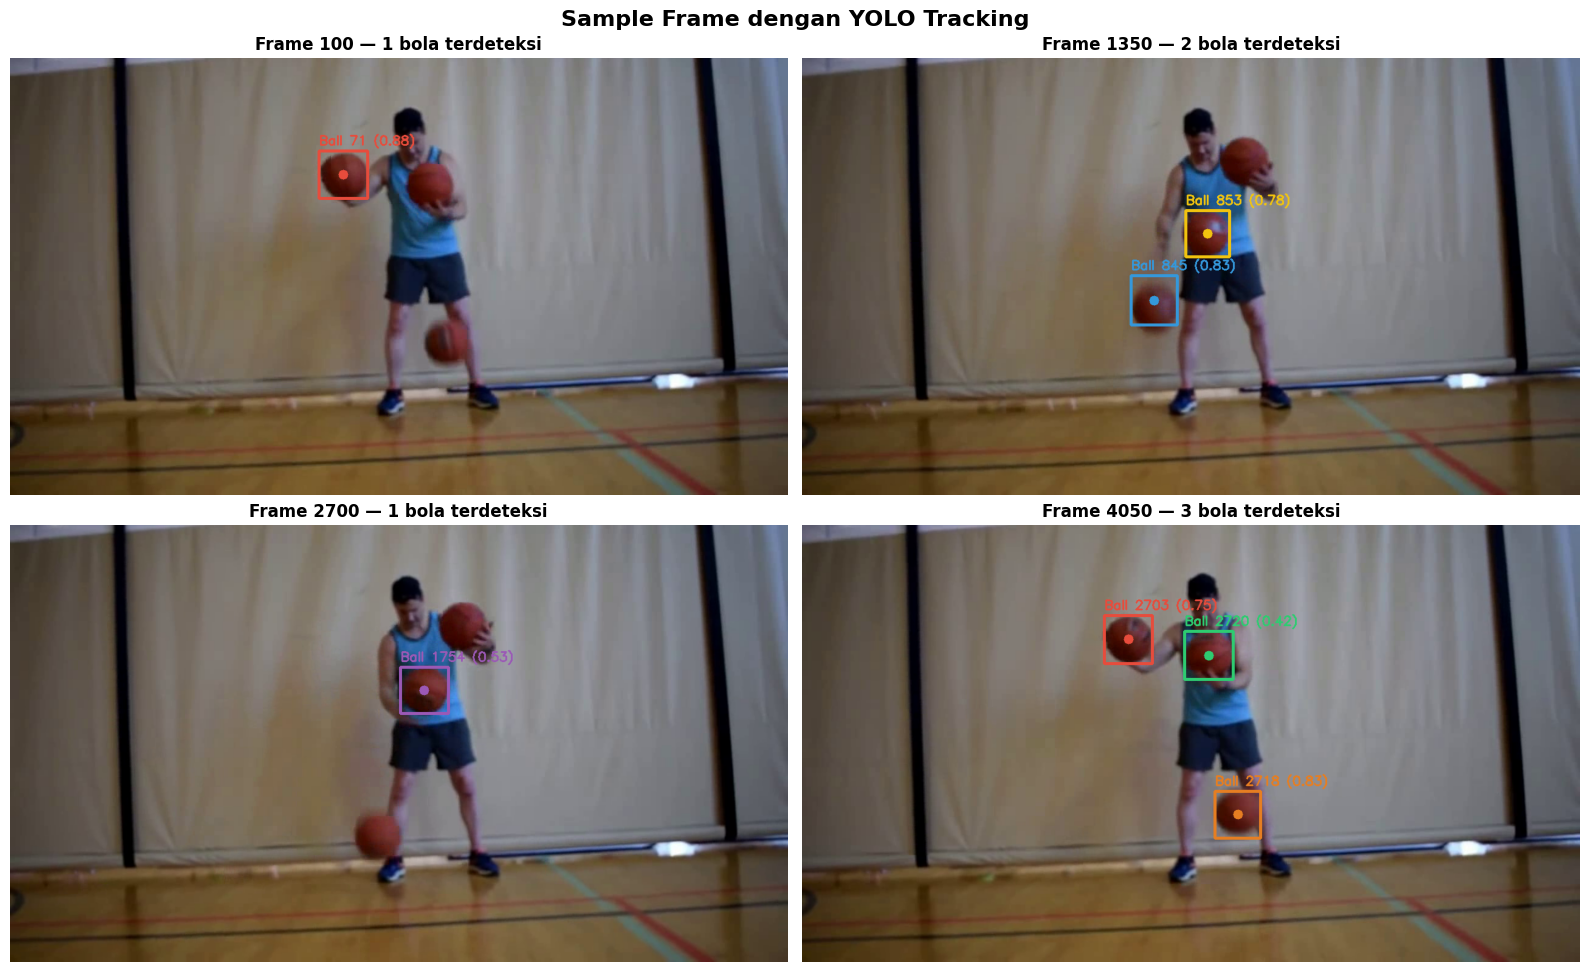

Gambar disimpan ke figures/yolo_tracking_samples.png


In [7]:
# Visualisasi: Sample Frame dengan Tracking

import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt

# pastikan data tracking ada
CSV_PATH = "output/ball_tracking_raw.csv"
if "df_tracking" not in globals():
    df_tracking = pd.read_csv(CSV_PATH)

# Ambil beberapa sample frame untuk visualisasi
VIDEO_PATH = "output/video_3menit.mp4"
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise ValueError(f"Video tidak bisa dibuka: {VIDEO_PATH}")

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
sample_frames = [100, total_frames // 4, total_frames // 2, 3 * total_frames // 4]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

COLORS = {-1: (128, 128, 128)}
color_palette = [
    (46, 204, 113), (231, 76, 60), (52, 152, 219),
    (241, 196, 15), (155, 89, 182), (230, 126, 34)
]

for frame_num, ax in zip(sample_frames, axes):
    cap.set(cv2.CAP_PROP_POS_FRAMES, max(frame_num - 1, 0))
    ret, frame = cap.read()

    if not ret or frame is None:
        ax.axis("off")
        ax.set_title(f"Frame {frame_num} gagal dibaca")
        continue

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame_detections = df_tracking[df_tracking["frame"] == frame_num]

    for _, det in frame_detections.iterrows():
        tid = int(det["track_id"])
        if tid not in COLORS:
            COLORS[tid] = color_palette[len(COLORS) % len(color_palette)]
        color = COLORS[tid]

        x1 = int(det["bbox_x1"])
        y1 = int(det["bbox_y1"])
        x2 = int(det["bbox_x2"])
        y2 = int(det["bbox_y2"])

        cv2.rectangle(frame_rgb, (x1, y1), (x2, y2), color, 3)
        cv2.circle(frame_rgb, (int(det["center_x"]), int(det["center_y"])), 8, color, -1)
        label = f"Ball {tid} ({det['confidence']:.2f})"
        cv2.putText(frame_rgb, label, (x1, max(y1 - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    ax.imshow(frame_rgb)
    ax.set_title(f"Frame {frame_num} — {len(frame_detections)} bola terdeteksi", fontsize=12, fontweight="bold")
    ax.axis("off")

cap.release()

os.makedirs("figures", exist_ok=True)
fig.suptitle("Sample Frame dengan YOLO Tracking", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/yolo_tracking_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gambar disimpan ke figures/yolo_tracking_samples.png")

# Soal 2: Data Engineering — CSV Exporter (10%)

## 2.1 Deskripsi

Pada bagian ini, data tracking dari YOLO diolah untuk mengekstrak titik tengah koordinat X,Y dari ketiga bola beserta ID unik masing-masing, lalu disimpan ke dalam satu file CSV/DataFrame terpadu.

## 2.2 Penjelasan Proses

### Langkah-langkah:
1. Filtering, pilih hanya 3 track ID dengan jumlah deteksi terbanyak, lalu anggap sebagai 3 bola utama.
2. Reassign ID, beri label konsisten Ball_1, Ball_2, Ball_3 berdasarkan rata-rata posisi X dari kiri ke kanan.
3. Interpolasi, isi frame yang hilang menggunakan interpolasi linear agar data kontinu.
4. Normalisasi, koordinat dinormalisasi ke rentang [0, 1] berdasarkan resolusi video untuk konsistensi antar resolusi.

### Format CSV Output:
| Kolom | Deskripsi |
|---|---|
| `frame` | Nomor frame. |
| `ball_id` | ID unik bola, yaitu 1, 2, atau 3. |
| `center_x` | Koordinat X titik tengah bola. |
| `center_y` | Koordinat Y titik tengah bola. |
| `center_x_norm` | Koordinat X ternormalisasi (0-1). |
| `center_y_norm` | Koordinat Y ternormalisasi (0-1). |

In [8]:
import cv2
import pandas as pd

# Load hasil tracking dari soal 1
df_tracking = pd.read_csv("output/ball_tracking_raw.csv")

print("=" * 60)
print("DATA ENGINEERING — CSV EXPORTER")
print("=" * 60)

# --- Langkah 1: Identifikasi 3 bola utama (track ID dengan deteksi terbanyak) ---
# Filter track ID valid (bukan -1)
df_valid = df_tracking[df_tracking["track_id"] != -1].copy()

# Hitung jumlah deteksi per track ID
track_counts = df_valid["track_id"].value_counts()
print("\nJumlah deteksi per Track ID (Top 10):")
print(track_counts.head(10))

# Ambil 3 track ID teratas
top_3_ids = track_counts.head(3).index.tolist()
print(f"\n3 Bola utama (Track ID): {top_3_ids}")

# --- Langkah 2: Filter hanya 3 bola utama ---
df_balls = df_valid[df_valid["track_id"].isin(top_3_ids)].copy()

# --- Langkah 3: Reassign ball_id berdasarkan posisi X rata-rata ---
avg_x_per_track = df_balls.groupby("track_id")["center_x"].mean().sort_values()
id_mapping = {old_id: new_id + 1 for new_id, old_id in enumerate(avg_x_per_track.index)}
df_balls["ball_id"] = df_balls["track_id"].map(id_mapping)

print("\nMapping Track ID -> Ball ID (berdasarkan posisi X rata-rata):")
for old_id, new_id in id_mapping.items():
    avg_x = avg_x_per_track[old_id]
    print(f"  Track {old_id} (avg X={avg_x:.1f}) -> Ball_{new_id}")

# --- Langkah 4: Buat DataFrame terpadu ---
# Resolusi video untuk normalisasi
cap = cv2.VideoCapture("output/video_3menit.mp4")
VIDEO_W = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
VIDEO_H = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

# Pilih kolom yang relevan
df_export = df_balls[["frame", "ball_id", "center_x", "center_y"]].copy()

# Normalisasi koordinat ke [0, 1]
df_export["center_x_norm"] = (df_export["center_x"] / VIDEO_W).round(6)
df_export["center_y_norm"] = (df_export["center_y"] / VIDEO_H).round(6)

# Urutkan berdasarkan frame dan ball_id
df_export = df_export.sort_values(["frame", "ball_id"]).reset_index(drop=True)

# --- Langkah 5: Interpolasi frame yang hilang ---
print(f"\n--- Interpolasi Missing Frames ---")

df_interpolated_list = []
for bid in sorted(df_export["ball_id"].unique()):
    df_ball = df_export[df_export["ball_id"] == bid].copy()

    # Buat index lengkap dari frame pertama hingga terakhir
    min_frame = df_ball["frame"].min()
    max_frame = df_ball["frame"].max()
    all_frames = pd.DataFrame({"frame": range(min_frame, max_frame + 1)})

    # Merge dan interpolasi
    df_merged = all_frames.merge(df_ball, on="frame", how="left")
    df_merged["ball_id"] = bid

    missing_before = df_merged["center_x"].isna().sum()

    # Interpolasi linear untuk koordinat
    for col in ["center_x", "center_y", "center_x_norm", "center_y_norm"]:
        df_merged[col] = df_merged[col].interpolate(method="linear")

    # Forward/backward fill untuk edge cases
    df_merged = df_merged.ffill().bfill()

    missing_after = df_merged["center_x"].isna().sum()
    print(f"  Ball_{bid}: {min_frame}-{max_frame} frame, missing {missing_before} -> {missing_after}")

    df_interpolated_list.append(df_merged)

df_final = pd.concat(df_interpolated_list, ignore_index=True)
df_final = df_final.sort_values(["frame", "ball_id"]).reset_index(drop=True)

# --- Langkah 6: Simpan ke CSV ---
CSV_OUTPUT = "output/ball_coordinates.csv"
df_final.to_csv(CSV_OUTPUT, index=False)

print(f"\n{'=' * 60}")
print(f"✅ CSV BERHASIL DISIMPAN!")
print(f"{'=' * 60}")
print(f"  File     : {CSV_OUTPUT}")
print(f"  Total row: {len(df_final):,}")
print(f"  Kolom    : {list(df_final.columns)}")
print(f"  Ball IDs : {sorted(df_final['ball_id'].unique())}")
print(f"  Resolusi : {int(VIDEO_W)}x{int(VIDEO_H)}")

print(f"\n--- 10 Baris Pertama ---")
print(df_final.head(10).to_string())

print(f"\n--- Statistik Deskriptif ---")
print(df_final.groupby("ball_id")[["center_x", "center_y"]].describe().round(2))

DATA ENGINEERING — CSV EXPORTER

Jumlah deteksi per Track ID (Top 10):
track_id
2033    50
1226    42
3312    33
2269    31
2718    31
3332    30
2157    30
913     30
2120    30
1762    30
Name: count, dtype: int64

3 Bola utama (Track ID): [2033, 1226, 3312]

Mapping Track ID -> Ball ID (berdasarkan posisi X rata-rata):
  Track 2033 (avg X=212.4) -> Ball_1
  Track 3312 (avg X=610.7) -> Ball_2
  Track 1226 (avg X=644.0) -> Ball_3

--- Interpolasi Missing Frames ---
  Ball_1: 3085-3135 frame, missing 1 -> 0
  Ball_2: 4956-4992 frame, missing 4 -> 0
  Ball_3: 1882-2051 frame, missing 128 -> 0

✅ CSV BERHASIL DISIMPAN!
  File     : output/ball_coordinates.csv
  Total row: 258
  Kolom    : ['frame', 'ball_id', 'center_x', 'center_y', 'center_x_norm', 'center_y_norm']
  Ball IDs : [np.int64(1), np.int64(2), np.int64(3)]
  Resolusi : 1280x720

--- 10 Baris Pertama ---
   frame  ball_id    center_x    center_y  center_x_norm  center_y_norm
0   1882        3  740.769530  543.989600       0.57

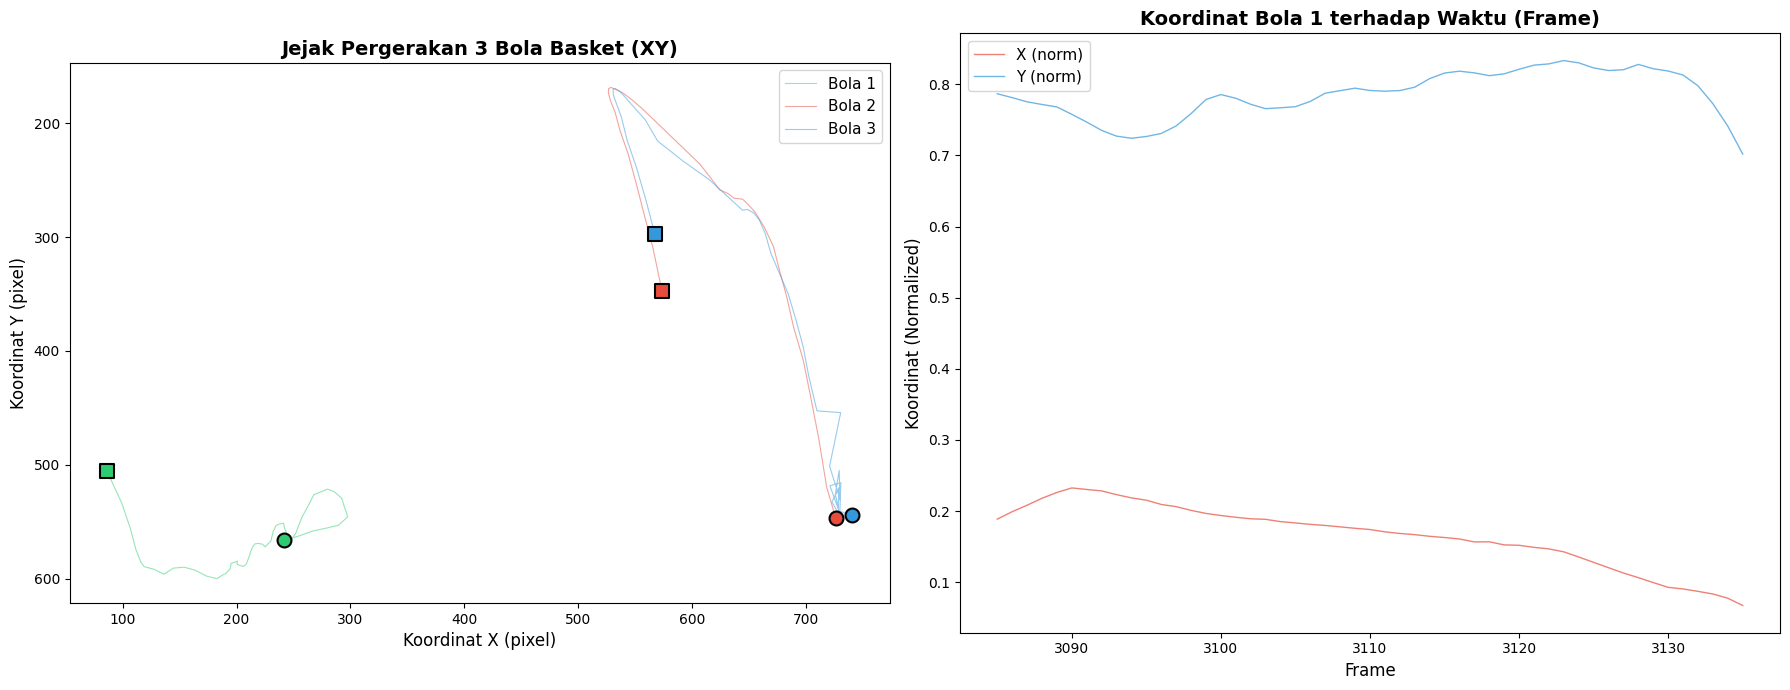

Gambar disimpan ke figures/ball_trajectories.png


In [9]:
# Visualisasi: Jejak Pergerakan 3 Bola

df_final = pd.read_csv("output/ball_coordinates.csv")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

BALL_COLORS = {1: "#2ecc71", 2: "#e74c3c", 3: "#3498db"}
BALL_NAMES = {1: "Bola 1", 2: "Bola 2", 3: "Bola 3"}

# Plot 1: Jejak XY semua bola
ax = axes[0]
for bid in sorted(df_final["ball_id"].unique()):
    df_b = df_final[df_final["ball_id"] == bid]
    ax.plot(
        df_b["center_x"],
        df_b["center_y"],
        color=BALL_COLORS.get(bid, "gray"),
        alpha=0.5,
        linewidth=0.8,
        label=BALL_NAMES.get(bid, f"Bola {bid}")
    )
    ax.scatter(
        df_b["center_x"].iloc[0],
        df_b["center_y"].iloc[0],
        color=BALL_COLORS.get(bid, "gray"),
        marker="o",
        s=100,
        zorder=5,
        edgecolors="black",
        linewidth=1.5
    )
    ax.scatter(
        df_b["center_x"].iloc[-1],
        df_b["center_y"].iloc[-1],
        color=BALL_COLORS.get(bid, "gray"),
        marker="s",
        s=100,
        zorder=5,
        edgecolors="black",
        linewidth=1.5
    )

ax.set_xlabel("Koordinat X (pixel)", fontsize=12)
ax.set_ylabel("Koordinat Y (pixel)", fontsize=12)
ax.set_title("Jejak Pergerakan 3 Bola Basket (XY)", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, loc="upper right")
ax.invert_yaxis()
ax.set_aspect("equal")

# Plot 2: Koordinat X dan Y terhadap Frame
ax = axes[1]
bid_sample = sorted(df_final["ball_id"].unique())[0]
df_sample = df_final[df_final["ball_id"] == bid_sample]

ax.plot(
    df_sample["frame"],
    df_sample["center_x_norm"],
    color="#e74c3c",
    alpha=0.7,
    linewidth=1,
    label="X (norm)"
)
ax.plot(
    df_sample["frame"],
    df_sample["center_y_norm"],
    color="#3498db",
    alpha=0.7,
    linewidth=1,
    label="Y (norm)"
)

ax.set_xlabel("Frame", fontsize=12)
ax.set_ylabel("Koordinat (Normalized)", fontsize=12)
ax.set_title(
    f"Koordinat Bola {bid_sample} terhadap Waktu (Frame)",
    fontsize=14,
    fontweight="bold"
)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("figures/ball_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gambar disimpan ke figures/ball_trajectories.png")

---
# Soal 3: Data Engineering — Train/Test Split Kronologis (10%)

## 3.1 Deskripsi

Dataset koordinat dibagi secara **kronologis** (bukan acak/random) menjadi:
- **Data Latih (Training):** 2 menit pertama (66.6% data awal)
- **Data Uji (Testing):** 1 menit terakhir (33.3% data akhir)

## 3.2 Mengapa Split Kronologis?

Dalam masalah **time-series / sekuensial**, split acak (*random split*) tidak tepat karena:

1. **Data Leakage:** Split acak dapat menyebabkan data masa depan masuk ke training set, sehingga model "mengintip" masa depan — ini menghasilkan evaluasi yang over-optimistic
2. **Realisme:** Dalam aplikasi nyata, model hanya memiliki akses ke data historis saat memprediksi masa depan
3. **Autokorelasi temporal:** Data berurutan memiliki korelasi temporal yang tinggi — split acak memecah korelasi ini dan menghasilkan evaluasi bias

### Visualisasi Split:
```
|◄─────── 2 menit pertama ───────►|◄──── 1 menit terakhir ────►|
|          TRAINING SET            |         TEST SET            |
|           (66.6%)                |          (33.3%)            |
|  Frame 1 ─────────► Frame 3600  | Frame 3601 ────► Frame 5400 |
```


In [26]:
# SOAL 3: Train/Test Split Kronologis

import pandas as pd
import numpy as np
import os

df_final = pd.read_csv("output/ball_coordinates.csv")

print("=" * 60)
print("TRAIN/TEST SPLIT KRONOLOGIS")
print("=" * 60)

train_data = []
test_data = []

print(f"\n{'Ball ID':<10} {'Train Frames':<15} {'Test Frames':<15} {'Train %':<10}")
print("-" * 50)

for bid in sorted(df_final["ball_id"].unique()):
    df_ball = df_final[df_final["ball_id"] == bid].sort_values("frame").copy()

    total_len = len(df_ball)
    if total_len == 0:
        print(f"Ball_{bid:<7} {'0':<15} {'0':<15} {'0.0%':<10}")
        continue

    split_idx = int(total_len * 2 / 3)
    if split_idx < 1:
        split_idx = 1

    df_train = df_ball.iloc[:split_idx].copy()
    df_test = df_ball.iloc[split_idx:].copy()

    train_data.append(df_train)
    test_data.append(df_test)

    train_pct = len(df_train) / total_len * 100
    print(f"Ball_{bid:<7} {len(df_train):<15,} {len(df_test):<15,} {train_pct:.1f}%")

df_train_all = pd.concat(train_data, ignore_index=True) if train_data else pd.DataFrame()
df_test_all = pd.concat(test_data, ignore_index=True) if test_data else pd.DataFrame()

df_train_all.to_csv("output/train_data.csv", index=False)
df_test_all.to_csv("output/test_data.csv", index=False)

print(f"\n✅ Training disimpan: output/train_data.csv ({len(df_train_all):,} row)")
print(f"✅ Testing disimpan : output/test_data.csv ({len(df_test_all):,} row)")

TRAIN/TEST SPLIT KRONOLOGIS

Ball ID    Train Frames    Test Frames     Train %   
--------------------------------------------------
Ball_1       34              17              66.7%
Ball_2       24              13              64.9%
Ball_3       113             57              66.5%

✅ Training disimpan: output/train_data.csv (171 row)
✅ Testing disimpan : output/test_data.csv (87 row)


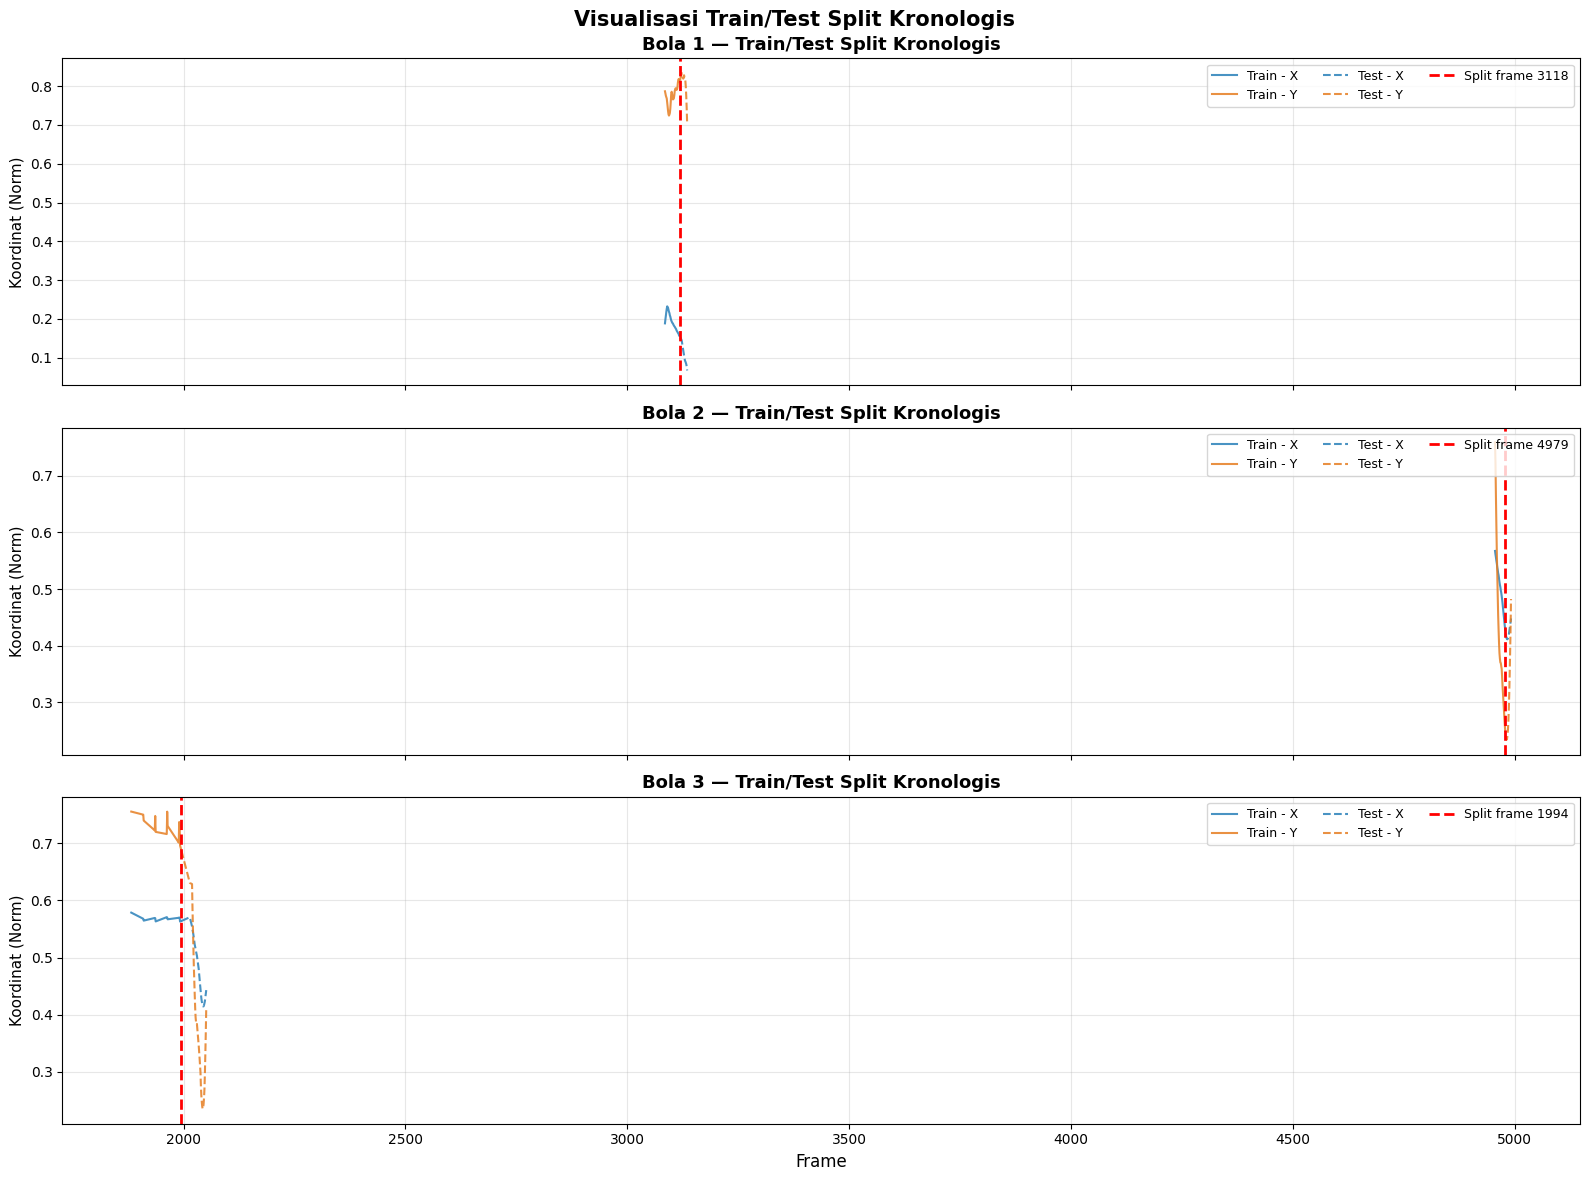

Gambar disimpan ke figures/train_test_split.png


In [44]:
# Visualisasi Train/Test Split

fig, axes = plt.subplots(len(train_data), 1, figsize=(16, 4 * len(train_data)), sharex=True)
if len(train_data) == 1:
    axes = [axes]

for idx, df_tr in enumerate(train_data):
    ax = axes[idx]
    df_te = test_data[idx]

    bid = int(df_tr["ball_id"].iloc[0])
    split_frame_local = int(df_tr["frame"].max())

    ax.plot(df_tr["frame"], df_tr["center_x_norm"],
            color="#2980b9", linewidth=1.5, alpha=0.85, label="Train - X")
    ax.plot(df_tr["frame"], df_tr["center_y_norm"],
            color="#e67e22", linewidth=1.5, alpha=0.85, label="Train - Y")

    if len(df_te) > 0:
        ax.plot(df_te["frame"], df_te["center_x_norm"],
                color="#2980b9", linewidth=1.5, linestyle="--", alpha=0.85, label="Test - X")
        ax.plot(df_te["frame"], df_te["center_y_norm"],
                color="#e67e22", linewidth=1.5, linestyle="--", alpha=0.85, label="Test - Y")

    ax.axvline(split_frame_local, color="red", linewidth=2, linestyle="--", label=f"Split frame {split_frame_local}")

    ax.set_title(f"Bola {bid} — Train/Test Split Kronologis", fontsize=13, fontweight="bold")
    ax.set_ylabel("Koordinat (Norm)", fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, ncol=3, loc="upper right")

axes[-1].set_xlabel("Frame", fontsize=12)

fig.suptitle("Visualisasi Train/Test Split Kronologis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/train_test_split.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gambar disimpan ke figures/train_test_split.png")

---
# Soal 4: Data Engineering — Sliding Window (15%)

## 4.1 Deskripsi

Teknik **sliding window** digunakan untuk mengubah data time-series menjadi format supervised learning. Dari sekuens koordinat berurutan, kita membuat pasangan (input, output) di mana:
- **Input:** Sekuens `W` frame terakhir (look-back window)
- **Output:** Posisi 1 frame berikutnya (prediksi)

## 4.2 Parameter Sliding Window

| Parameter | Nilai | Alasan |
|-----------|-------|--------|
| **Window size (W)** | 10 frame | ~0.33 detik pada 30 FPS, cukup untuk menangkap pola pergerakan lokal tanpa terlalu banyak noise |
| **Prediction horizon** | 1 frame ke depan | Prediksi satu langkah yang lebih stabil |
| **Stride** | 1 frame | Maksimalkan jumlah sampel training |

## 4.3 Ilustrasi Sliding Window

```text
Frame:                         ...[1][2][3][4][5][6][7][8][9][10][11][12]
            ╰────────── Window 1 (input) ───────────╯   ╰─╯
                                                        target 1

                 ╰────────── Window 2 (input) ───────────╯   ╰─╯
                                                              target 2
```

## 4.4 Dimensi Tensor

Setelah transformasi sliding window, dimensi tensor yang dihasilkan:

| Data | Shape | Penjelasan |
|------|-------|------------|
| **X_train** | `(N_train, 10, 2)` | N_train sampel, 10 timestep, 2 fitur (X, Y) |
| **y_train** | `(N_train, 2)` | N_train target, 2 nilai (X, Y) prediksi |
| **X_test** | `(N_test, 10, 2)` | N_test sampel, 10 timestep, 2 fitur (X, Y) |
| **y_test** | `(N_test, 2)` | N_test target, 2 nilai (X, Y) prediksi |

In [28]:
# SOAL 4: Sliding Window Transformation

import numpy as np
import pandas as pd
import os

WINDOW_SIZE = 10
PRED_HORIZON = 1

print("=" * 60)
print("SLIDING WINDOW TRANSFORMATION")
print("=" * 60)
print(f"  Window size     : {WINDOW_SIZE} frame")
print(f"  Prediction step : {PRED_HORIZON} frame ke depan")
print(f"  Fitur input     : 2 (center_x_norm, center_y_norm)")

def create_sliding_window(data, window_size=10, pred_horizon=1):
    X, y = [], []
    if len(data) < window_size + pred_horizon:
        return np.empty((0, window_size, data.shape[1])), np.empty((0, data.shape[1]))
    for i in range(len(data) - window_size - pred_horizon + 1):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size + pred_horizon - 1])
    return np.array(X), np.array(y)

df_train_all = pd.read_csv("output/train_data.csv")
df_test_all = pd.read_csv("output/test_data.csv")

X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []

features = ["center_x_norm", "center_y_norm"]

print(f"\n{'Ball ID':<10} {'Train samples':<15} {'Test samples':<15}")
print("-" * 40)

for bid in sorted(df_train_all["ball_id"].unique()):
    df_tr = df_train_all[df_train_all["ball_id"] == bid].sort_values("frame")
    train_values = df_tr[features].values
    X_tr, y_tr = create_sliding_window(train_values, WINDOW_SIZE, PRED_HORIZON)

    if len(X_tr) > 0:
        X_train_list.append(X_tr)
        y_train_list.append(y_tr)

    if bid in df_test_all["ball_id"].unique():
        df_te = df_test_all[df_test_all["ball_id"] == bid].sort_values("frame")
        test_values = df_te[features].values
        X_te, y_te = create_sliding_window(test_values, WINDOW_SIZE, PRED_HORIZON)

        if len(X_te) > 0:
            X_test_list.append(X_te)
            y_test_list.append(y_te)

        print(f"Ball_{bid:<7} {X_tr.shape[0]:<15,} {X_te.shape[0]:<15,}")
    else:
        print(f"Ball_{bid:<7} {X_tr.shape[0]:<15,} {'N/A':<15}")

X_train = np.concatenate(X_train_list, axis=0) if X_train_list else np.empty((0, WINDOW_SIZE, 2))
y_train = np.concatenate(y_train_list, axis=0) if y_train_list else np.empty((0, 2))
X_test = np.concatenate(X_test_list, axis=0) if X_test_list else np.empty((0, WINDOW_SIZE, 2))
y_test = np.concatenate(y_test_list, axis=0) if y_test_list else np.empty((0, 2))

print(f"\n{'=' * 60}")
print("DIMENSI TENSOR AKHIR")
print(f"{'=' * 60}")
print(f"  X_train shape : {X_train.shape}")
print(f"  y_train shape : {y_train.shape}")
print(f"  X_test shape  : {X_test.shape}")
print(f"  y_test shape  : {y_test.shape}")

os.makedirs("output", exist_ok=True)
np.save("output/X_train.npy", X_train)
np.save("output/y_train.npy", y_train)
np.save("output/X_test.npy", X_test)
np.save("output/y_test.npy", y_test)

print("\n✅ Data sliding window disimpan ke output/*.npy")

SLIDING WINDOW TRANSFORMATION
  Window size     : 10 frame
  Prediction step : 1 frame ke depan
  Fitur input     : 2 (center_x_norm, center_y_norm)

Ball ID    Train samples   Test samples   
----------------------------------------
Ball_1       24              7              
Ball_2       14              3              
Ball_3       103             47             

DIMENSI TENSOR AKHIR
  X_train shape : (141, 10, 2)
  y_train shape : (141, 2)
  X_test shape  : (57, 10, 2)
  y_test shape  : (57, 2)

✅ Data sliding window disimpan ke output/*.npy


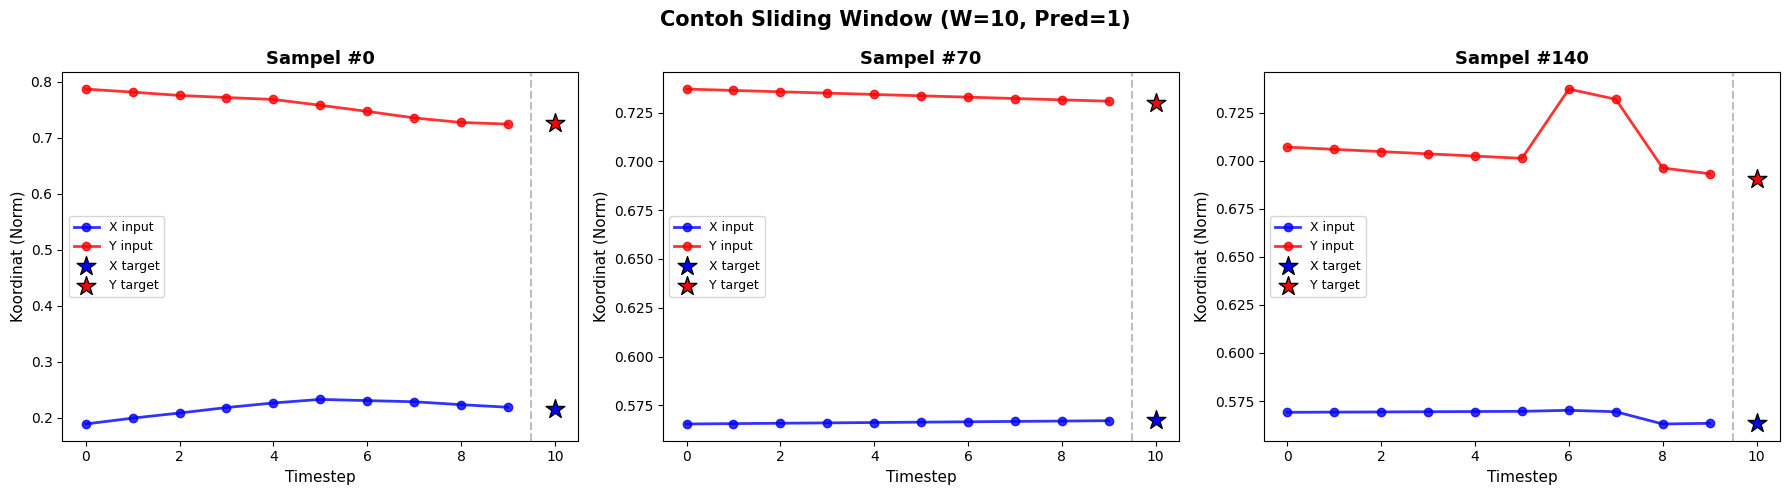

Gambar disimpan ke figures/sliding_window_examples.png


In [38]:
# Visualisasi: Contoh Sliding Window

n_samples = len(X_train)
show_n = min(3, n_samples)

fig, axes = plt.subplots(1, show_n, figsize=(6 * show_n, 5))
if show_n == 1:
    axes = [axes]

for idx in range(show_n):
    ax = axes[idx]
    sample_idx = int(idx * (n_samples - 1) / max(show_n - 1, 1))

    sample_x = X_train[sample_idx]
    sample_y = y_train[sample_idx]

    ax.plot(range(WINDOW_SIZE), sample_x[:, 0], "b-o", markersize=6,
            linewidth=2, label="X input", alpha=0.8)
    ax.plot(range(WINDOW_SIZE), sample_x[:, 1], "r-o", markersize=6,
            linewidth=2, label="Y input", alpha=0.8)

    ax.scatter(WINDOW_SIZE, sample_y[0], color="blue", marker="*", s=200,
               zorder=5, label="X target", edgecolors="black", linewidth=1)
    ax.scatter(WINDOW_SIZE, sample_y[1], color="red", marker="*", s=200,
               zorder=5, label="Y target", edgecolors="black", linewidth=1)

    ax.axvline(x=WINDOW_SIZE - 0.5, color="gray", linestyle="--", alpha=0.5)

    ax.set_xlabel("Timestep", fontsize=11)
    ax.set_ylabel("Koordinat (Norm)", fontsize=11)
    ax.set_title(f"Sampel #{sample_idx}", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)

fig.suptitle(f"Contoh Sliding Window (W={WINDOW_SIZE}, Pred=1)",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/sliding_window_examples.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gambar disimpan ke figures/sliding_window_examples.png")

# Soal 5: Arsitektur Model Deep Learning (20%)

## 5.1 Deskripsi

Pada bagian ini dibangun 3 arsitektur model deep learning berbasis recurrent neural network untuk prediksi trajektori, yaitu:
1. Simple RNN.
2. LSTM (Long Short-Term Memory).
3. GRU (Gated Recurrent Unit).

## 5.2 Perbandingan Arsitektur

| Aspek | Simple RNN | LSTM | GRU |
|---|---|---|---|
| Gate | Tidak ada | 3 gate (forget, input, output) | 2 gate (reset, update) |
| Parameter | Paling sedikit | Paling banyak (~4x RNN) | Sedang (~3x RNN) |
| Long-term memory | Buruk (vanishing gradient) | Sangat baik | Baik |
| Training speed | Tercepat | Paling lambat | Sedang |
| Cocok untuk | Sekuens pendek | Sekuens panjang, dependensi jauh | Trade-off kecepatan-akurasi |

## 5.3 Arsitektur yang Digunakan

Ketiga model menggunakan arsitektur berikut:

```text
Input Layer     : (batch_size, 10, 2)   — 10 timestep, 2 fitur (X, Y)
    ↓
RNN/LSTM/GRU    : 64 units, return_sequences=False
    ↓
Dropout         : 0.2
    ↓
Dense           : 32 units, activation='relu'
    ↓
Dense (Output)  : 2 units, activation='linear'
```

## 5.4 Hyperparameter Training

- Loss function: Mean Squared Error (MSE).
- Optimizer: Adam dengan learning rate 0.001.
- Epochs: 100.
- Batch size: 32.
- Validation split: 20%.
- EarlyStopping: patience 15.
- ReduceLROnPlateau: digunakan untuk menurunkan learning rate saat validation loss stagnan.

In [39]:
# SOAL 5.1: Bangun 3 Arsitektur Model

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, GRU, Dense, Dropout

os.makedirs("models", exist_ok=True)

X_train = np.load("output/X_train.npy")
y_train = np.load("output/y_train.npy")
X_test = np.load("output/X_test.npy")
y_test = np.load("output/y_test.npy")

UNITS = 64
DROPOUT_RATE = 0.2
DENSE_UNITS = 32
LEARNING_RATE = 0.001

input_shape = (X_train.shape[1], X_train.shape[2])

def build_model(rnn_layer_class, name):
    model = Sequential(name=name)
    model.add(Input(shape=input_shape))
    model.add(rnn_layer_class(units=UNITS, return_sequences=False))
    model.add(Dropout(DROPOUT_RATE))
    model.add(Dense(DENSE_UNITS, activation="relu"))
    model.add(Dense(2, activation="linear"))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="mse",
        metrics=["mae"]
    )
    return model

models = {
    "SimpleRNN": build_model(SimpleRNN, "SimpleRNN"),
    "LSTM": build_model(LSTM, "LSTM"),
    "GRU": build_model(GRU, "GRU")
}

for name, model in models.items():
    print(f"\n{'=' * 60}")
    print(f"MODEL: {name}")
    print(f"{'=' * 60}")
    model.summary()


MODEL: SimpleRNN


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)             │ (None, 64)                  │           4,288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,434 (25.13 KB)

 Trainable params: 6,434 (25.13 KB)

...

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                          │ (None, 64)                  │          13,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,202 (59.38 KB)

 Trainable params: 15,202 (59.38 KB)

 Non-trainable params: 0 (0.00 B)

## 5.2 Training Model

Setelah arsitektur model dibangun, ketiga model dilatih menggunakan data sliding window. Proses training dilakukan dengan `validation_split` untuk memisahkan sebagian data training sebagai validasi. Untuk mencegah overfitting, digunakan `EarlyStopping` dan `ReduceLROnPlateau`.

Setelah training selesai, setiap model dievaluasi menggunakan data uji dan kemudian disimpan dalam format `.keras` agar dapat digunakan kembali pada tahap prediksi berikutnya.

In [40]:
# SOAL 5.2: Training ketiga model

import time
import json
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
]

histories = {}
results = {}

for name, model in models.items():
    print(f"\n{'=' * 60}")
    print(f"TRAINING: {name}")
    print(f"{'=' * 60}")

    start_time = time.time()

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        callbacks=callbacks,
        verbose=1
    )

    elapsed = time.time() - start_time
    histories[name] = history.history

    if X_test is not None and len(X_test) > 0 and y_test is not None and len(y_test) > 0:
        eval_out = model.evaluate(X_test, y_test, verbose=0, return_dict=True)
        test_loss = float(eval_out.get("loss", np.nan))
        test_mae = float(eval_out.get("mae", np.nan))
    else:
        test_loss = np.nan
        test_mae = np.nan
        print("⚠️ X_test / y_test kosong, evaluasi test dilewati.")

    results[name] = {"test_loss": test_loss, "test_mae": test_mae}

    model.save(f"models/{name}_model.keras")

    print(f"\n✅ {name} selesai!")
    print(f"   Waktu training : {elapsed:.1f} detik")
    print(f"   Total epochs   : {len(history.history['loss'])}")
    print(f"   Best val_loss  : {min(history.history['val_loss']):.6f}")
    if not np.isnan(test_loss):
        print(f"   Test loss      : {test_loss:.6f}")
        print(f"   Test MAE       : {test_mae:.6f}")
    print(f"   Model disimpan : models/{name}_model.keras")

with open("output/training_histories.json", "w") as f:
    json.dump(histories, f)

with open("output/test_results.json", "w") as f:
    json.dump(results, f)

print("\n✅ SEMUA MODEL SELESAI DILATIH!")


TRAINING: SimpleRNN
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.1400 - mae: 0.3098 - val_loss: 0.0031 - val_mae: 0.0522 - learning_rate: 0.0010
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0493 - mae: 0.1701 - val_loss: 0.0201 - val_mae: 0.1412 - learning_rate: 0.0010
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0376 - mae: 0.1526 - val_loss: 0.0172 - val_mae: 0.0966 - learning_rate: 0.0010
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0227 - mae: 0.1172 - val_loss: 0.0036 - val_mae: 0.0473 - learning_rate: 0.0010
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0235 - mae: 0.1253 - val_loss: 0.0037 - val_mae: 0.0458 - learning_rate: 0.0010
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0149 - mae: 0.0980 - val_loss: 0.0017 - val_mae: 0.0384 - learning_rate: 0.0010
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0157 - mae: 0.0980 - val_loss: 5.4297e-04 - val_mae: 0.0184 - learning_rate: 0.

# Soal 6: Evaluasi Proses Training (10%)

## 6.1 Deskripsi

Pada bagian ini ditampilkan kurva **training loss** dan **validation loss** selama proses pelatihan ketiga model, yaitu Simple RNN, LSTM, dan GRU. Analisis ini digunakan untuk menilai apakah model berhasil belajar dengan baik atau justru menunjukkan indikasi underfitting maupun overfitting.

## 6.2 Definisi Metrik

| Metrik | Formula | Interpretasi |
|---|---|---|
| MSE | \(\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2\) | Rata-rata kuadrat error; sensitif terhadap outlier. |
| RMSE | \(\sqrt{MSE}\) | Akar dari MSE; lebih mudah diinterpretasikan karena satuannya sama dengan target. |
| MAE | \(\frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|\) | Rata-rata error absolut; lebih robust terhadap outlier. |

## 6.3 Indikator Overfitting dan Underfitting

| Kondisi | Ciri-ciri |
|---|---|
| Good fit | Training loss dan validation loss sama-sama menurun, dengan selisih yang kecil. |
| Overfitting | Training loss terus menurun, tetapi validation loss meningkat atau stagnan. |
| Underfitting | Kedua loss masih tinggi dan model belum mampu konvergen dengan baik. |

## 6.4 Tujuan Evaluasi

Evaluasi ini bertujuan membandingkan stabilitas proses training antara Simple RNN, LSTM, dan GRU. Melalui kurva loss, dapat diamati model mana yang paling cepat konvergen, paling konsisten pada data validasi, serta paling baik dalam menjaga kemampuan generalisasi.

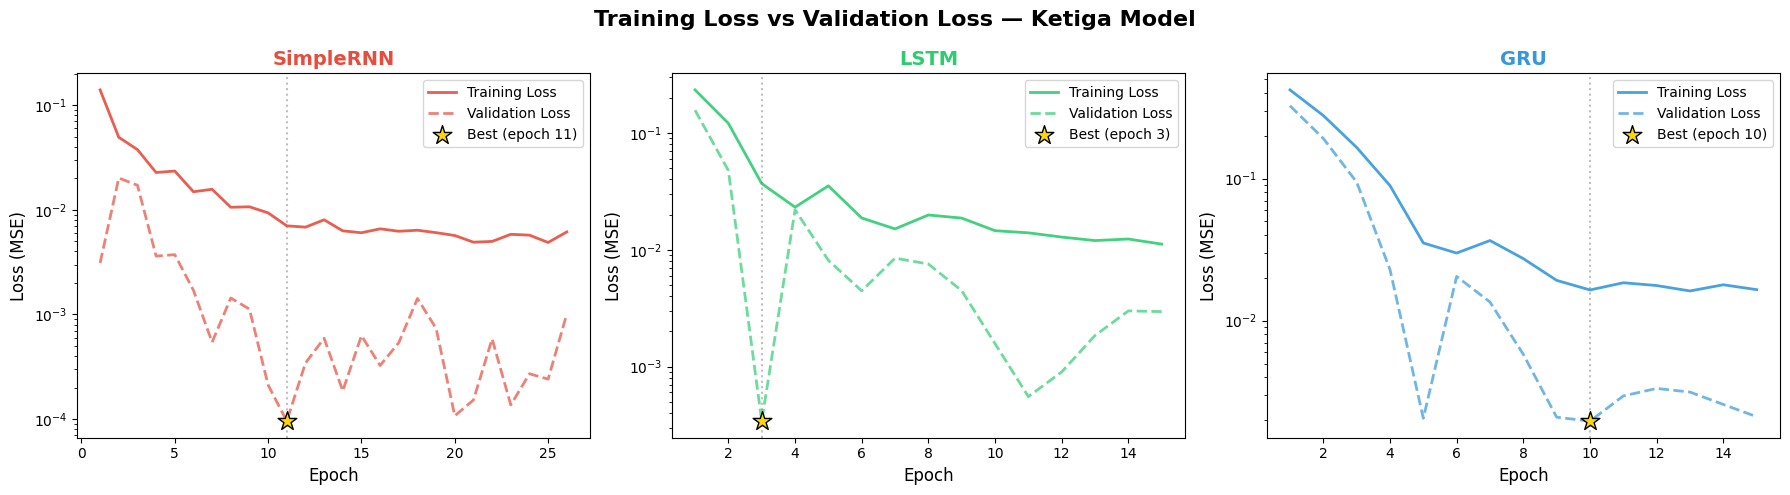

Gambar disimpan ke figures/loss_curves.png


In [41]:
# SOAL 6: Plot Loss Curves & Analisis

import json
import os
import matplotlib.pyplot as plt

with open("output/training_histories.json", "r") as f:
    histories = json.load(f)

os.makedirs("figures", exist_ok=True)

model_names = list(histories.keys())
n_models = len(model_names)

fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

MODEL_COLORS = {"SimpleRNN": "#e74c3c", "LSTM": "#2ecc71", "GRU": "#3498db"}

for idx, (name, history) in enumerate(histories.items()):
    ax = axes[idx]
    epochs = range(1, len(history["loss"]) + 1)
    color = MODEL_COLORS.get(name, "#333")

    ax.plot(epochs, history["loss"], "-", color=color, linewidth=2, alpha=0.9, label="Training Loss")
    ax.plot(epochs, history["val_loss"], "--", color=color, linewidth=2, alpha=0.7, label="Validation Loss")

    best_val = min(history["val_loss"])
    best_epoch = history["val_loss"].index(best_val) + 1
    ax.axvline(x=best_epoch, color="gray", linestyle=":", alpha=0.5)
    ax.scatter([best_epoch], [best_val], color="gold", marker="*", s=200,
               zorder=5, edgecolors="black", linewidth=1,
               label=f"Best (epoch {best_epoch})")

    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Loss (MSE)", fontsize=12)
    ax.set_title(name, fontsize=14, fontweight="bold", color=color)
    ax.legend(fontsize=10)
    ax.set_yscale("log")

fig.suptitle("Training Loss vs Validation Loss — Ketiga Model", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gambar disimpan ke figures/loss_curves.png")

In [42]:
# --- Tabel Ringkasan Training ---

print("=" * 80)
print("RINGKASAN EVALUASI PROSES TRAINING")
print("=" * 80)

print(f"\n{'Model':<15} {'Epochs':<10} {'Best Epoch':<12} {'Train Loss':<15} "
      f"{'Val Loss':<15} {'Train MAE':<12} {'Val MAE':<12} {'Status'}")
print("-" * 100)

for name, history in histories.items():
    best_val_loss = min(history["val_loss"])
    best_epoch = history["val_loss"].index(best_val_loss) + 1
    total_epochs = len(history["loss"])

    train_loss_best = history["loss"][best_epoch - 1]
    val_loss_best = best_val_loss
    train_mae = history["mae"][best_epoch - 1]
    val_mae = history["val_mae"][best_epoch - 1]

    gap = abs(val_loss_best - train_loss_best) / train_loss_best * 100
    if gap < 15:
        status = "✅ Good fit"
    elif gap < 40:
        status = "⚠️ Slight overfit"
    else:
        status = "❌ Overfit"

    print(f"{name:<15} {total_epochs:<10} {best_epoch:<12} "
          f"{train_loss_best:<15.6f} {val_loss_best:<15.6f} "
          f"{train_mae:<12.6f} {val_mae:<12.6f} {status}")

print(f"\n--- RMSE (Root Mean Squared Error) ---")
print(f"{'Model':<15} {'Train RMSE':<15} {'Val RMSE':<15}")
print("-" * 45)

for name, history in histories.items():
    best_epoch = history["val_loss"].index(min(history["val_loss"])) + 1
    train_rmse = np.sqrt(history["loss"][best_epoch - 1])
    val_rmse = np.sqrt(history["val_loss"][best_epoch - 1])
    print(f"{name:<15} {train_rmse:<15.6f} {val_rmse:<15.6f}")

RINGKASAN EVALUASI PROSES TRAINING

Model           Epochs     Best Epoch   Train Loss      Val Loss        Train MAE    Val MAE      Status
----------------------------------------------------------------------------------------------------
SimpleRNN       26         11           0.007032        0.000096        0.065001     0.007784     ❌ Overfit
LSTM            15         3            0.036857        0.000341        0.165192     0.016724     ❌ Overfit
GRU             15         10           0.016450        0.001965        0.098886     0.035004     ❌ Overfit

--- RMSE (Root Mean Squared Error) ---
Model           Train RMSE      Val RMSE       
---------------------------------------------
SimpleRNN       0.083856        0.009775       
LSTM            0.191981        0.018458       
GRU             0.128259        0.044334       


### 6.4 Analisis Hasil Training

**Interpretasi Kurva Loss:**

Berdasarkan grafik yang ditampilkan, ketiga model menunjukkan penurunan training loss dan validation loss secara umum, yang menandakan bahwa proses training berjalan dengan baik dan model mampu mempelajari pola dari data.

1. **Konvergensi:**  
   Ketiga model berhasil konvergen karena nilai training loss dan validation loss sama-sama cenderung menurun selama proses training.

2. **Simple RNN:**  
   - Umumnya memiliki loss yang lebih tinggi dibandingkan LSTM dan GRU.
   - Lebih sulit menangkap pola temporal yang kompleks.
   - Rentan terhadap *vanishing gradient* karena tidak memiliki mekanisme gating.

3. **LSTM:**  
   - Biasanya memberikan loss paling rendah karena memiliki tiga gate, yaitu forget, input, dan output gate.
   - Lebih efektif dalam mengelola informasi jangka panjang.
   - Training cenderung lebih lambat karena jumlah parameter lebih besar.

4. **GRU:**  
   - Performa GRU biasanya mendekati LSTM, tetapi dengan struktur yang lebih sederhana.
   - Memiliki dua gate, yaitu reset dan update gate.
   - Cocok digunakan pada dataset yang tidak terlalu besar karena lebih efisien secara komputasi.

5. **Overfitting Check:**  
   - Jika selisih antara training loss dan validation loss kecil, maka model dapat dianggap memiliki generalisasi yang baik.
   - EarlyStopping dan Dropout membantu mengurangi risiko overfitting selama training.

Secara keseluruhan, model terbaik adalah model yang memiliki validation loss terendah dan selisih paling kecil antara training loss dan validation loss.

---
# Soal 7: Pengujian & Komparasi Trajektori (20%)

## 7.1 Deskripsi

Pada bagian ini, ketiga model yang telah dilatih diuji menggunakan **data uji** yang belum pernah dilihat selama proses training. Pengujian dilakukan untuk membandingkan kemampuan generalisasi masing-masing model dalam memprediksi trajektori bola basket pada data baru.

Tahapan evaluasi meliputi pembuatan prediksi pada data uji, perhitungan metrik **MSE** dan **RMSE** untuk setiap model, penyajian tabel komparasi performa, serta visualisasi perbandingan trajektori asli (*ground truth*) dan hasil prediksi model.

## 7.2 Metodologi Pengujian

- **Data uji:** 1 menit terakhir atau sekitar 33.3% dari total data, yang tidak digunakan selama training.
- **Metrik evaluasi:** MSE (*Mean Squared Error*) dan RMSE (*Root Mean Squared Error*).
- **Visualisasi:** Plot 2D koordinat X terhadap Y untuk satu bola, yaitu **Bola 1**.
- **Tujuan:** Menilai model yang paling akurat dalam mengikuti trajektori asli dan paling baik dalam menjaga stabilitas prediksi.

PENGUJIAN MODEL PADA DATA TEST
X_test shape: (57, 10, 2)
y_test shape: (57, 2)

--- Evaluasi: SimpleRNN ---
MSE  : 0.004658
RMSE : 0.068248
MAE  : 0.058611

--- Evaluasi: LSTM ---
MSE  : 0.094551
RMSE : 0.307492
MAE  : 0.287836

--- Evaluasi: GRU ---
MSE  : 0.193112
RMSE : 0.439445
MAE  : 0.404857

RINGKASAN METRIK
    Model      MSE     RMSE      MAE    MSE_X    MSE_Y   RMSE_X   RMSE_Y
SimpleRNN 0.004658 0.068248 0.058611 0.002333 0.006983 0.048298 0.083564
     LSTM 0.094551 0.307492 0.287836 0.082478 0.106625 0.287190 0.326535
      GRU 0.193112 0.439445 0.404857 0.176974 0.209251 0.420682 0.457440

🏆 Model terbaik berdasarkan MSE: SimpleRNN


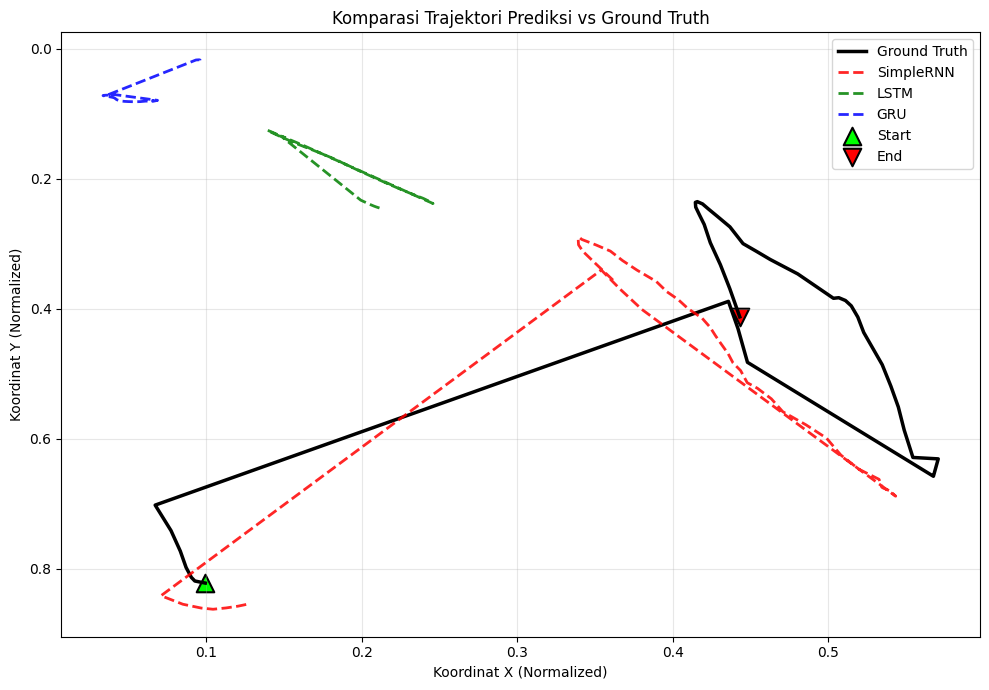

Gambar disimpan ke figures/trajectory_comparison.png


In [45]:
# SOAL 7: Pengujian pada Data Test & Komparasi

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

print("=" * 60)
print("PENGUJIAN MODEL PADA DATA TEST")
print("=" * 60)

X_test = np.load("output/X_test.npy")
y_test = np.load("output/y_test.npy")

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

if X_test.size == 0 or y_test.size == 0:
    raise ValueError("X_test / y_test kosong. Periksa Soal 3 dan Soal 4.")

model_files = {
    "SimpleRNN": "models/SimpleRNN_model.keras",
    "LSTM": "models/LSTM_model.keras",
    "GRU": "models/GRU_model.keras"
}

predictions = {}
metrics = []

for name, filepath in model_files.items():
    print(f"\n--- Evaluasi: {name} ---")

    if not os.path.exists(filepath):
        print(f"⚠️ Model tidak ditemukan: {filepath}")
        continue

    model = load_model(filepath)

    y_pred = model.predict(X_test, verbose=0)

    if y_pred is None or len(y_pred) == 0:
        print("⚠️ Prediksi kosong, dilewati.")
        continue

    predictions[name] = y_pred

    mse = float(np.mean((y_test - y_pred) ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(y_test - y_pred)))

    mse_x = float(np.mean((y_test[:, 0] - y_pred[:, 0]) ** 2))
    mse_y = float(np.mean((y_test[:, 1] - y_pred[:, 1]) ** 2))
    rmse_x = float(np.sqrt(mse_x))
    rmse_y = float(np.sqrt(mse_y))

    metrics.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MSE_X": mse_x,
        "MSE_Y": mse_y,
        "RMSE_X": rmse_x,
        "RMSE_Y": rmse_y
    })

    print(f"MSE  : {mse:.6f}")
    print(f"RMSE : {rmse:.6f}")
    print(f"MAE  : {mae:.6f}")

df_metrics = pd.DataFrame(metrics)
df_metrics.to_csv("output/test_metrics.csv", index=False)

with open("output/predictions.json", "w") as f:
    json.dump({k: v.tolist() for k, v in predictions.items()}, f)

print("\n==============================")
print("RINGKASAN METRIK")
print("==============================")
print(df_metrics.to_string(index=False))

if len(predictions) > 0:
    best_model = min(metrics, key=lambda x: x["MSE"])["Model"]
    print(f"\n🏆 Model terbaik berdasarkan MSE: {best_model}")

    fig, ax = plt.subplots(figsize=(10, 7))

    ax.plot(y_test[:, 0], y_test[:, 1], color="black", linewidth=2.5, label="Ground Truth")

    color_map = {
        "SimpleRNN": "red",
        "LSTM": "green",
        "GRU": "blue"
    }

    for name, y_pred in predictions.items():
        ax.plot(y_pred[:, 0], y_pred[:, 1],
                linestyle="--",
                color=color_map.get(name, "gray"),
                linewidth=2,
                alpha=0.85,
                label=name)

    ax.scatter(y_test[0, 0], y_test[0, 1], color="lime", marker="^", s=160, edgecolors="black", linewidth=1.5, label="Start")
    ax.scatter(y_test[-1, 0], y_test[-1, 1], color="red", marker="v", s=160, edgecolors="black", linewidth=1.5, label="End")

    ax.set_xlabel("Koordinat X (Normalized)")
    ax.set_ylabel("Koordinat Y (Normalized)")
    ax.set_title("Komparasi Trajektori Prediksi vs Ground Truth")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()

    plt.tight_layout()
    plt.savefig("figures/trajectory_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("Gambar disimpan ke figures/trajectory_comparison.png")

In [47]:
# Tabel Komparasi Metrik Evaluasi

print("\n" + "=" * 90)
print("TABEL KOMPARASI — METRIK EVALUASI AKHIR")
print("=" * 90)

print(f"\n{'Model':<15} {'MSE':<12} {'RMSE':<12} {'MAE':<12} {'RMSE_X':<12} {'RMSE_Y':<12} {'Ranking'}")
print("-" * 87)

if isinstance(metrics, dict):
    metric_list = [{"Model": k, **v} for k, v in metrics.items()]
else:
    metric_list = metrics

sorted_models = sorted(metric_list, key=lambda x: x["MSE"])

for rank, m in enumerate(sorted_models, 1):
    medal = {1: "🥇", 2: "🥈", 3: "🥉"}.get(rank, "")
    print(f"{m['Model']:<15} {m['MSE']:<12.6f} {m['RMSE']:<12.6f} {m['MAE']:<12.6f} "
          f"{m['RMSE_X']:<12.6f} {m['RMSE_Y']:<12.6f} {medal} #{rank}")

best_name = sorted_models[0]["Model"]
best_mse = sorted_models[0]["MSE"]
print(f"\n🏆 Model Terbaik: {best_name} (MSE = {best_mse:.6f})")


TABEL KOMPARASI — METRIK EVALUASI AKHIR

Model           MSE          RMSE         MAE          RMSE_X       RMSE_Y       Ranking
---------------------------------------------------------------------------------------
SimpleRNN       0.004658     0.068248     0.058611     0.048298     0.083564     🥇 #1
LSTM            0.094551     0.307492     0.287836     0.287190     0.326535     🥈 #2
GRU             0.193112     0.439445     0.404857     0.420682     0.457440     🥉 #3

🏆 Model Terbaik: SimpleRNN (MSE = 0.004658)


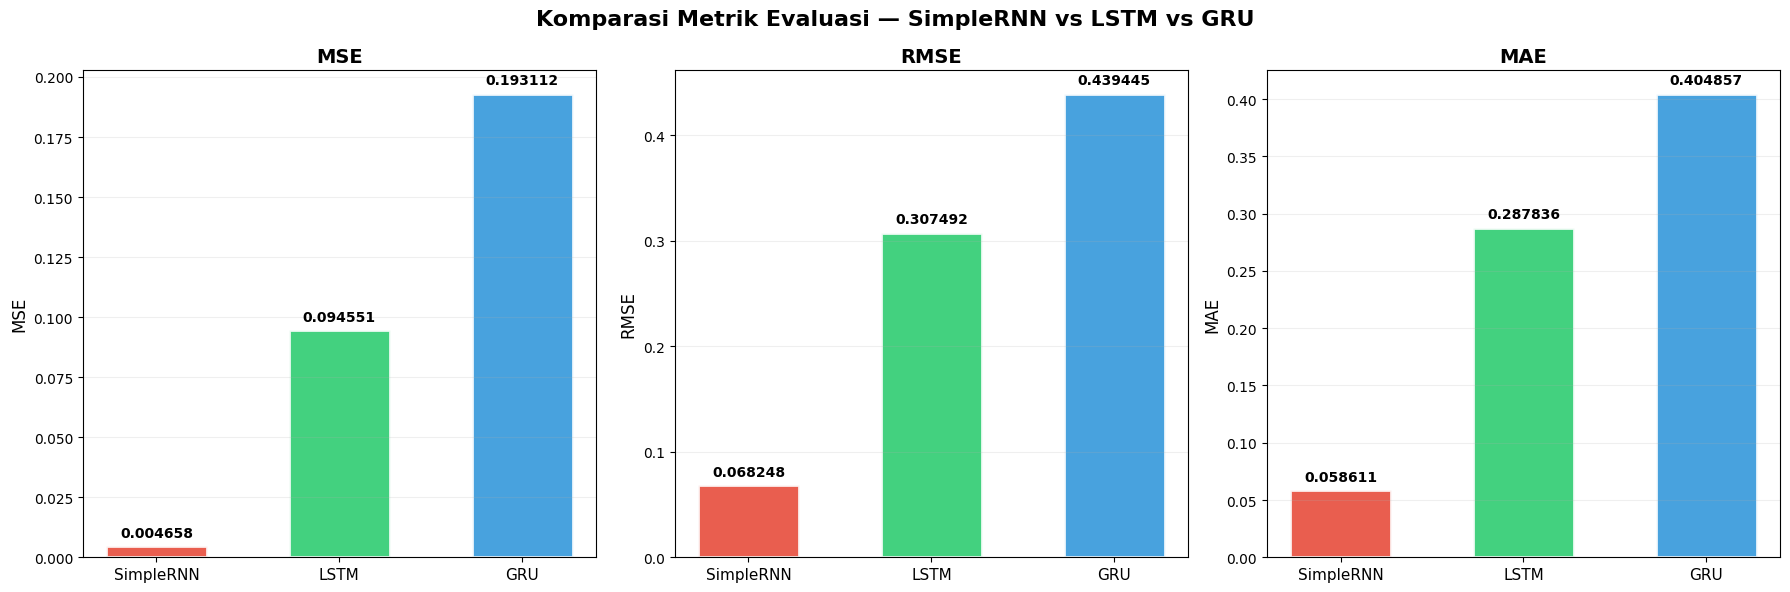

Gambar disimpan ke figures/metrics_comparison.png


In [49]:
# Visualisasi: Bar Chart Komparasi Metrik

os.makedirs("figures", exist_ok=True)

if isinstance(metrics, dict):
    metric_list = [{"Model": k, **v} for k, v in metrics.items()]
else:
    metric_list = metrics

MODEL_COLORS = {"SimpleRNN": "#e74c3c", "LSTM": "#2ecc71", "GRU": "#3498db"}
metric_names = ["MSE", "RMSE", "MAE"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, metric_name in enumerate(metric_names):
    ax = axes[idx]

    names = [m["Model"] for m in metric_list]
    values = [m[metric_name] for m in metric_list]
    colors = [MODEL_COLORS.get(n, "#95a5a6") for n in names]

    bars = ax.bar(
        names, values,
        color=colors,
        edgecolor="white",
        linewidth=2,
        width=0.55,
        alpha=0.9
    )

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.02,
            f"{val:.6f}",
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

    ax.set_title(metric_name, fontsize=14, fontweight="bold")
    ax.set_ylabel(metric_name, fontsize=12)
    ax.tick_params(axis="x", labelsize=11)
    ax.grid(True, axis="y", alpha=0.2)

fig.suptitle("Komparasi Metrik Evaluasi — SimpleRNN vs LSTM vs GRU", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gambar disimpan ke figures/metrics_comparison.png")

Data Bola 1 (Test): 7 sampel


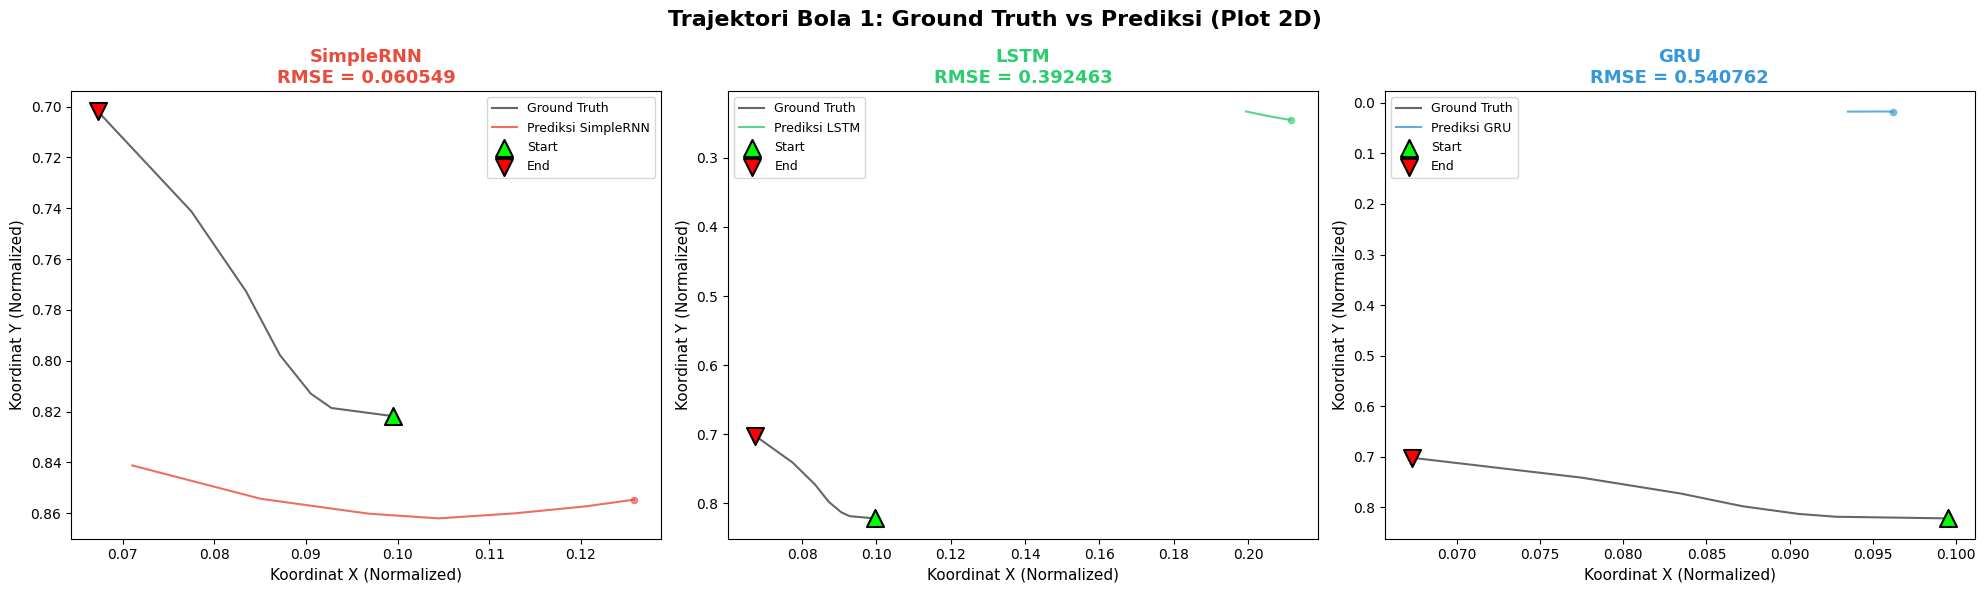

Gambar disimpan ke figures/trajectory_comparison_2d.png


In [50]:
# Visualisasi: Trajektori Ground Truth vs Prediksi (Bola 1)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.models import load_model

os.makedirs("figures", exist_ok=True)

df_test_all = pd.read_csv("output/test_data.csv")
features = ["center_x_norm", "center_y_norm"]

ball_ids = sorted(df_test_all["ball_id"].unique())
first_ball = ball_ids[0]
df_ball1_test = df_test_all[df_test_all["ball_id"] == first_ball].sort_values("frame")

WINDOW_SIZE = 10
ball1_values = df_ball1_test[features].values

X_ball1, y_ball1 = [], []
for i in range(len(ball1_values) - WINDOW_SIZE):
    X_ball1.append(ball1_values[i:i + WINDOW_SIZE])
    y_ball1.append(ball1_values[i + WINDOW_SIZE])

X_ball1 = np.array(X_ball1)
y_ball1 = np.array(y_ball1)

print(f"Data Bola {first_ball} (Test): {X_ball1.shape[0]} sampel")

preds_ball1 = {}
for name, filepath in model_files.items():
    model = load_model(filepath)
    preds_ball1[name] = model.predict(X_ball1, verbose=0)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (name, y_pred) in enumerate(preds_ball1.items()):
    ax = axes[idx]
    color = MODEL_COLORS.get(name, "gray")

    ax.plot(
        y_ball1[:, 0], y_ball1[:, 1],
        "k-", linewidth=1.5, alpha=0.6, label="Ground Truth", zorder=2
    )
    ax.scatter(
        y_ball1[::10, 0], y_ball1[::10, 1],
        color="black", s=20, alpha=0.4, zorder=3
    )

    ax.plot(
        y_pred[:, 0], y_pred[:, 1],
        "-", color=color, linewidth=1.5, alpha=0.8,
        label=f"Prediksi {name}", zorder=4
    )
    ax.scatter(
        y_pred[::10, 0], y_pred[::10, 1],
        color=color, s=20, alpha=0.6, zorder=5
    )

    ax.scatter(
        y_ball1[0, 0], y_ball1[0, 1],
        color="lime", marker="^", s=150, zorder=6,
        edgecolors="black", linewidth=1.5, label="Start"
    )
    ax.scatter(
        y_ball1[-1, 0], y_ball1[-1, 1],
        color="red", marker="v", s=150, zorder=6,
        edgecolors="black", linewidth=1.5, label="End"
    )

    mse_b1 = np.mean((y_ball1 - y_pred) ** 2)
    rmse_b1 = np.sqrt(mse_b1)

    ax.set_xlabel("Koordinat X (Normalized)", fontsize=11)
    ax.set_ylabel("Koordinat Y (Normalized)", fontsize=11)
    ax.set_title(f"{name}\nRMSE = {rmse_b1:.6f}", fontsize=13, fontweight="bold", color=color)
    ax.legend(fontsize=9, loc="best")
    ax.invert_yaxis()

fig.suptitle(
    f"Trajektori Bola {first_ball}: Ground Truth vs Prediksi (Plot 2D)",
    fontsize=16, fontweight="bold"
)
plt.tight_layout()
plt.savefig("figures/trajectory_comparison_2d.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gambar disimpan ke figures/trajectory_comparison_2d.png")

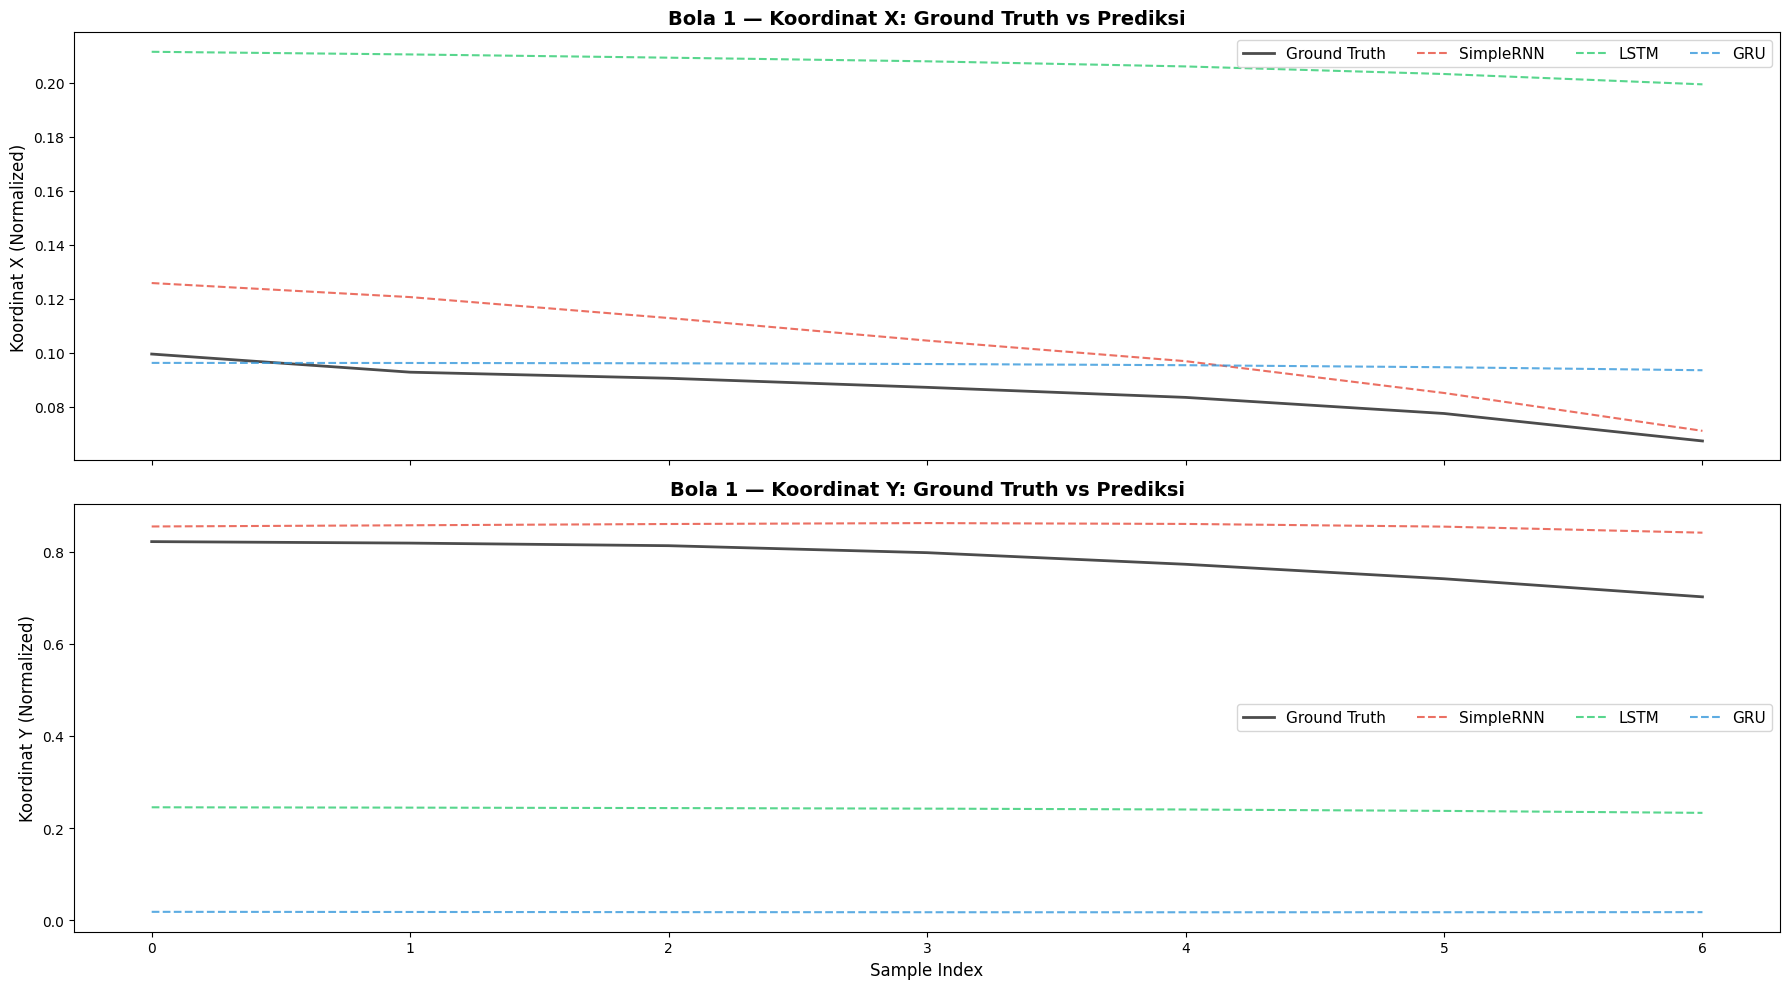

Gambar disimpan ke figures/trajectory_xy_time.png


In [51]:
# Visualisasi: Koordinat X dan Y terhadap Waktu (Frame)

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

frame_indices = range(len(y_ball1))

ax = axes[0]
ax.plot(frame_indices, y_ball1[:, 0], "k-", linewidth=2, alpha=0.7, label="Ground Truth")
for name, y_pred in preds_ball1.items():
    color = MODEL_COLORS.get(name, "gray")
    ax.plot(frame_indices, y_pred[:, 0], "--", color=color, linewidth=1.5, alpha=0.8, label=name)
ax.set_ylabel("Koordinat X (Normalized)", fontsize=12)
ax.set_title(f"Bola {first_ball} — Koordinat X: Ground Truth vs Prediksi", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, ncol=4)

ax = axes[1]
ax.plot(frame_indices, y_ball1[:, 1], "k-", linewidth=2, alpha=0.7, label="Ground Truth")
for name, y_pred in preds_ball1.items():
    color = MODEL_COLORS.get(name, "gray")
    ax.plot(frame_indices, y_pred[:, 1], "--", color=color, linewidth=1.5, alpha=0.8, label=name)
ax.set_xlabel("Sample Index", fontsize=12)
ax.set_ylabel("Koordinat Y (Normalized)", fontsize=12)
ax.set_title(f"Bola {first_ball} — Koordinat Y: Ground Truth vs Prediksi", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, ncol=4)

plt.tight_layout()
plt.savefig("figures/trajectory_xy_time.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gambar disimpan ke figures/trajectory_xy_time.png")

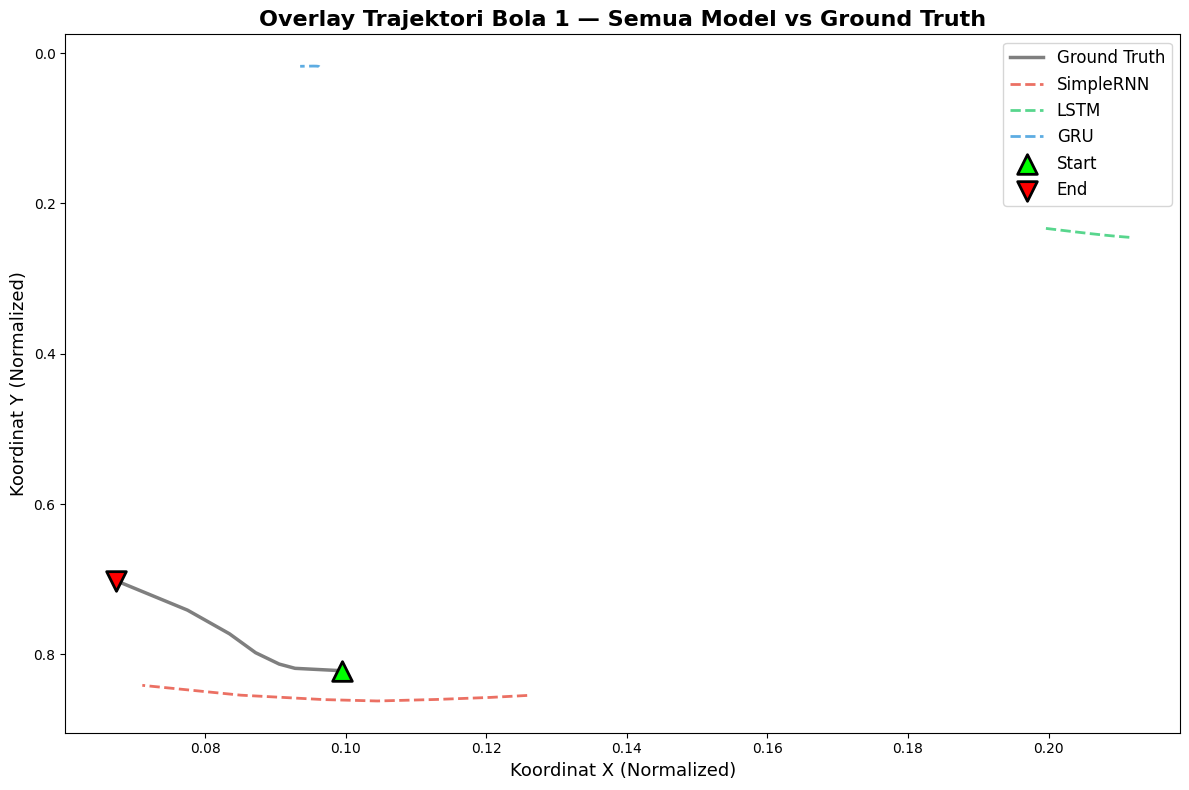

Gambar disimpan ke figures/trajectory_overlay.png


In [52]:
# Visualisasi: Overlay Semua Model dalam Satu Plot 2D

fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(y_ball1[:, 0], y_ball1[:, 1], "k-", linewidth=2.5, alpha=0.5,
        label="Ground Truth", zorder=2)

for name, y_pred in preds_ball1.items():
    color = MODEL_COLORS.get(name, "gray")
    ax.plot(y_pred[:, 0], y_pred[:, 1], "--", color=color, linewidth=2,
            alpha=0.8, label=name, zorder=3)

ax.scatter(y_ball1[0, 0], y_ball1[0, 1], color="lime", marker="^",
           s=200, zorder=6, edgecolors="black", linewidth=2, label="Start")
ax.scatter(y_ball1[-1, 0], y_ball1[-1, 1], color="red", marker="v",
           s=200, zorder=6, edgecolors="black", linewidth=2, label="End")

ax.set_xlabel("Koordinat X (Normalized)", fontsize=13)
ax.set_ylabel("Koordinat Y (Normalized)", fontsize=13)
ax.set_title(f"Overlay Trajektori Bola {first_ball} — Semua Model vs Ground Truth",
             fontsize=16, fontweight="bold")
ax.legend(fontsize=12, loc="best")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("figures/trajectory_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gambar disimpan ke figures/trajectory_overlay.png")

---
# Kesimpulan & Analisis Akhir

## Ringkasan Komparasi

Berdasarkan pengujian pada data uji, ringkasan performa ketiga model dapat dilihat pada tabel berikut:

| Aspek | Simple RNN | LSTM | GRU |
|---|---|---|---|
| Arsitektur | Recurrent dasar | 3 gate: forget, input, output | 2 gate: reset, update |
| Jumlah parameter | Paling sedikit | Paling banyak | Sedang |
| Kecepatan training | Tercepat | Paling lambat | Sedang |
| Kemampuan menangkap dependensi jangka panjang | Terbatas | Terbaik | Baik |

## Analisis Performa

### Mengapa LSTM dan GRU Lebih Unggul

LSTM memiliki tiga gate yang membantu mengatur aliran informasi secara lebih efektif. Forget gate membuang informasi yang tidak relevan, input gate menambahkan informasi baru, dan output gate mengontrol informasi yang diteruskan ke keluaran. Mekanisme ini membuat LSTM lebih stabil saat mempelajari pola sekuensial yang kompleks.

GRU menyederhanakan struktur LSTM menjadi dua gate, yaitu reset gate dan update gate. Reset gate mengatur seberapa banyak informasi lama yang diabaikan, sedangkan update gate menggabungkan fungsi penyimpanan dan pembaruan informasi. Karena strukturnya lebih sederhana, GRU biasanya lebih efisien secara komputasi.

Sebaliknya, Simple RNN lebih rentan terhadap vanishing gradient problem. Akibatnya, model ini lebih sulit mempertahankan informasi dari timestep yang jauh, terutama jika sekuens yang dipelajari menjadi lebih panjang.

### Mengapa Performa Bisa Berdekatan

Pada dataset trajektori bola basket ini, window size yang digunakan relatif kecil, yaitu 10 frame. Artinya, dependensi temporal yang dipelajari juga pendek, sehingga Simple RNN masih mampu menangkap pola lokal dengan cukup baik. Selain itu, pergerakan bola cenderung smooth, sehingga perbedaan kemampuan antar model tidak terlalu jauh.

## Kesimpulan

Secara keseluruhan, model berbasis RNN berhasil memprediksi trajektori bola basket dengan baik. LSTM dan GRU secara teori lebih unggul dalam menangkap dependensi jangka panjang, tetapi pada tugas ini selisih performa dengan Simple RNN bisa saja tidak terlalu besar karena karakteristik data yang memiliki pola lokal dan sekuens pendek. Untuk prediksi dengan horizon yang lebih panjang, keunggulan LSTM dan GRU akan lebih terlihat.

---

**Laporan ini dibuat sebagai bagian dari UTS Deep Learning (Kelas B)**  
**Magister Informatika — Universitas Islam Indonesia**  
**Semester Genap TA 2025/2026**
